**Instituto Tecnológico y de Estudios Superiores de Monterrey. Campus en Línea**

**Maestría en Inteligencia Artificial Aplicada**

Proyecto integrador (Gpo 10)

Profesores titulares: Dra. Grettel Barceló Alonso &  Dr. Luis Eduardo Falcón Morales

Profesora asistente: Mtra. Verónica Sandra Guzmán de Valle

**Equipo 22:**

* Juan Felipe Toro Salgado A01794247

* Luis Fernando Caporal Montes de Oca A01795898

* Hugo Santiago Martínez Martínez A01283080

Patrocinador: Ing. Pedro Eduardo González Rodríguez

# Proyecto: Mantenimiento proactivo basado en IA para hidroeléctricas 1–10 MW

**Avance 3. Baseline**

# **Importación de librerías y conexión a Google Drive**

In [1]:
# Conexión a Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest # Módelo de ML

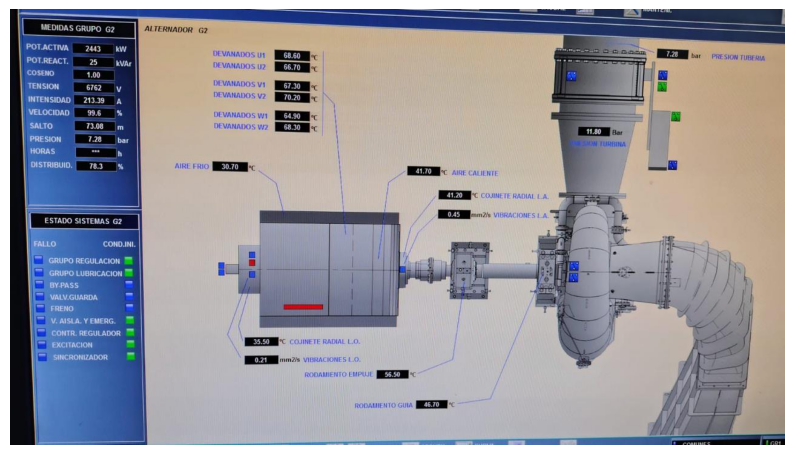

In [3]:
# Se retoman los datos analizados en el Avance 1: EDA
# A continuación, se presenta una imagen que visualiza el sistema que vamos a medir.
imagen_SCADA = '/content/drive/MyDrive/Proyecto Integrador - MNA Eq. 22/0. Información compartida /Fotografías Hidroeléctrica/SCADA_hidro.jpeg'
plt.figure(figsize=(10,8))
imagen_central = plt.imread(imagen_SCADA)
plt.imshow(imagen_central)
plt.axis('off')
plt.show()

In [4]:
# Data compartida por el usuario final
df_1 = pd.read_excel('/content/drive/MyDrive/Proyecto Integrador - MNA Eq. 22/0. Información compartida /Data_Trend/Variables temperatura de G1 (parte 1).xlsx')
df_2 = pd.read_excel('/content/drive/MyDrive/Proyecto Integrador - MNA Eq. 22/0. Información compartida /Data_Trend/Variables de temperatura y vibraciones de G1 (parte 2).xlsx')

In [5]:
# Crear una estampa de tiempo completa (FECHA + HORA)

# Convertir HORA a texto HH:MM:SS
hora_1 = pd.to_datetime(df_1['HORA'].astype(str), format='%H:%M:%S', errors='coerce').dt.strftime('%H:%M:%S')
hora_2 = pd.to_datetime(df_2['HORA'].astype(str), format='%H:%M:%S', errors='coerce').dt.strftime('%H:%M:%S')

# Crear TIMESTAMP (FECHA + HORA)
df_1['TIMESTAMP'] = pd.to_datetime(df_1['FECHA'].dt.strftime('%Y-%m-%d') + ' ' + hora_1, errors='coerce')
df_2['TIMESTAMP'] = pd.to_datetime(df_2['FECHA'].dt.strftime('%Y-%m-%d') + ' ' + hora_2, errors='coerce')

# Unión de los dos dataframes
data_trend = df_1.merge(df_2.drop(columns=['FECHA', 'HORA']), on='TIMESTAMP', how='inner')
data_trend =data_trend.set_index('TIMESTAMP')

In [6]:
data_trend.head(5)

,FECHA,HORA,G1-TEMPERATURA DEVANADO U1 ValueY,G1-TEMPERATURA DEVANADO U2 ValueY,G1-TEMPERATURA DEVANADO V1 ValueY,G1-TEMPERATURA DEVANADO V2 ValueY,G1-TEMPERATURA DEVANADO W1 ValueY,G1-TEMPERATURA DEVANADO W2 ValueY,G1-TEMPERATURA AIRE CALIENTE ValueY,G1-TEMPERATURA AIRE FRIO ValueY,G1-TEMPERATURA COJINETE LA ValueY,G1-TEMPERATURA RODAMIENTO EMPUJE ValueY,G1-TEMPERATURA COJINETE RADIAL LO ValueY,G1-TEMPERATURA RODAMIENTO GUIA ValueY,G1-VIBRACION COJINETE LA ValueY,G1-VIBRACION COJINETE LO ValueY,G1-TEMPERATURA ACEITE GL ValueY,G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY
TIMESTAMP,,,,,,,,,,,,,,,,,,
2026-01-12 00:00:08,2026-01-12,00:00:08,61.700001,65.5,62.700001,61.799999,62.200001,60.799999,36.900002,25.200001,38.799999,56.900002,31.200001,49.700001,0.314497,0.299946,55.5,42.200001
2026-01-12 00:00:18,2026-01-12,00:00:18,61.700001,65.5,62.700001,61.799999,62.200001,60.799999,36.900002,25.200001,38.900002,56.900002,31.200001,49.700001,0.293751,0.317522,55.5,42.200001
2026-01-12 00:00:28,2026-01-12,00:00:28,61.700001,65.5,62.700001,61.799999,62.200001,60.799999,36.900002,25.100000,38.900002,56.900002,31.200001,49.700001,0.281650,0.332649,55.5,42.200001
2026-01-12 00:00:38,2026-01-12,00:00:38,61.700001,65.5,62.700001,61.799999,62.200001,60.799999,36.900002,25.100000,38.799999,56.900002,31.200001,49.700001,0.278480,0.335530,55.5,42.200001
2026-01-12 00:00:48,2026-01-12,00:00:48,61.700001,65.5,62.700001,61.799999,62.200001,60.799999,36.900002,25.100000,38.799999,56.900002,31.200001,49.700001,0.273006,0.340429,55.5,42.200001


# **Marco teórico del Avance 2 – Ingeniería de características**

# **Introducción**

El objetivo principal de este avance es desarrollar la ingeniería de características a partir de los hallazgos más representativos identificados durante el Análisis Exploratorio de Datos (EDA). A partir de dicho análisis, se seleccionan, transforman y construyen variables relevantes que permiten capturar de manera más precisa el comportamiento subyacente del sistema bajo estudio.

La finalidad de este proceso es preparar y estructurar el conjunto de datos para que pueda ser utilizado de forma adecuada como entrada de un modelo de machine learning, asegurando que la información contenida en los datos sea informativa, consistente y alineada con el objetivo del modelado. De esta manera, la ingeniería de características se plantea como un paso clave para mejorar el desempeño, la interpretabilidad y la capacidad predictiva del modelo en etapas posteriores.

# **Desarrollo**

## **¿Cuál es el objetivo prinicpal del modelo de ML?**

Aprender el comportamiento normal multivariable del sistema turbina–generador y detectar desviaciones tempranas que indiquen degradación incipiente, así como la presencia de condiciones anómalas sostenidas durante la operación.

Por lo anterior, se requiere un modelo de Machine Learning capaz de identificar cuándo el sistema deja de comportarse de acuerdo con su patrón operativo normal, aun cuando no se haya producido una falla evidente.

Este modelo se fundamenta en un enfoque de detección de anomalías, donde el aprendizaje se realiza a partir de datos históricos de operación considerados normales.

Para este último punto, vale la pena describir qué es una anomalía:

## **¿Qué es una anomalía?**

Una anomalía se define como una combinación de variables que nunca, o casi nunca, ocurre durante la operación normal del sistema.

Dichas combinaciones pueden representar desviaciones sutiles en el comportamiento del equipo, las cuales podrían estar asociadas a procesos de degradación progresiva o a condiciones anómalas que, de persistir en el tiempo, podrían derivar en una falla.

Por el momento, se cuenta con un conjunto de datos de 138,240 registros correspondientes a 15 días de análisis, compuesto por 18 variables, en su mayoría asociadas a temperaturas y vibraciones del sistema turbina–generador. Este conjunto de datos se considera multivariado y resulta adecuado para el entrenamiento de modelos no supervisados, así como para la realización de análisis de correlaciones físicas reales entre las variables del sistema.

## **Por ende, el objetivo de este trabajo es:**
Vamos a construir la base de datos de aprendizaje para un modelo de detección temprana de anomalías en un sistema turbina–generador, sin etiquetas de falla. Por ende, el modelo aprende qué es normal.

# **Funciones auxiliares**

In [7]:
def plot_grafica(data_trend, variables, bins=30, figsize=(16, 4), rotate_xticks=90):

    """
    Esta función genera visualizaciones exploratorias para un conjunto de variables de un DataFrame temporal.

    Para cada variable se crean tres gráficos:
    1) Histograma + KDE → distribución estadística
    2) Boxplot → detección rápida de dispersión y outliers
    3) Serie temporal → comportamiento en el tiempo

    Parámetros:
    data_trend : pd.DataFrame
    variables : Lista de nombres de columnas a graficar.
    bins : Número de bins para el histograma.
    figsize : Tamaño de la figura (ancho, alto).
    rotate_xticks : Rotación de etiquetas del eje X para mejorar legibilidad.
    """

    for variable in variables:
        if variable not in data_trend.columns:
            print(f"[AVISO] '{variable}' no está en data_trend.columns. Se omite.")
            continue

        serie = data_trend[variable]
        datos = serie.dropna()
        if datos.empty:
            print(f"[AVISO] '{variable}' no tiene datos (todo NaN). Se omite.")
            continue

        tiempo = serie.index

        media = np.mean(datos)
        mediana = np.median(datos)
        std = np.std(datos)

        fig, ax = plt.subplots(1, 3, figsize=figsize)

        # Histograma
        ax[0].hist(datos, bins=bins, density=True, alpha=0.6)
        sns.kdeplot(datos, ax=ax[0])
        ax[0].axvline(media, color='red', linestyle='--', label=f'Media {media:.2f}')
        ax[0].axvline(mediana, color='green', linestyle='-.', label=f'Mediana {mediana:.2f}')
        ax[0].axvspan(media - std, media + std, alpha=0.15, label='±1σ')
        ax[0].set_title('Distribución')
        ax[0].legend()

        # Boxplot
        ax[1].boxplot(datos, vert=False, showmeans=True, meanline=True)
        ax[1].set_title('Boxplot')

        # DataTrend
        ax[2].plot(tiempo, serie)
        ax[2].axhline(media, color='red', linestyle='--')
        ax[2].set_title('Tendencia temporal')
        ax[2].set_xlabel('Tiempo')
        ax[2].set_ylabel('Valores')
        ax[2].grid(alpha=0.3)
        ax[2].tick_params(axis='x', rotation=rotate_xticks)

        fig.suptitle(
            f'{variable}  |  μ={media:.2f}  σ={std:.2f}  min={datos.min():.2f}  max={datos.max():.2f}'
        )
        plt.tight_layout()
        plt.show()
        print("")

# **Paso 0: Análisis exploratorio de datos (EDA)**

In [8]:
data_trend.columns

Index(['FECHA', 'HORA', 'G1-TEMPERATURA DEVANADO U1 ValueY',
       'G1-TEMPERATURA DEVANADO U2 ValueY',
       'G1-TEMPERATURA DEVANADO V1 ValueY',
       'G1-TEMPERATURA DEVANADO V2 ValueY',
       'G1-TEMPERATURA DEVANADO W1 ValueY',
       'G1-TEMPERATURA DEVANADO W2 ValueY',
       'G1-TEMPERATURA AIRE CALIENTE ValueY',
       'G1-TEMPERATURA AIRE FRIO ValueY', 'G1-TEMPERATURA COJINETE LA ValueY',
       'G1-TEMPERATURA RODAMIENTO EMPUJE ValueY',
       'G1-TEMPERATURA COJINETE RADIAL LO ValueY',
       'G1-TEMPERATURA RODAMIENTO GUIA ValueY',
       'G1-VIBRACION  COJINETE LA ValueY', 'G1-VIBRACION  COJINETE LO ValueY',
       'G1-TEMPERATURA ACEITE GL ValueY',
       'G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY'],
      dtype='object')

In [9]:
# A continuación se presenta una lista de las variables (todas numéricas) que serán analizadas en esta fase
variables_iniciales = [
       'G1-TEMPERATURA DEVANADO U1 ValueY',
       'G1-TEMPERATURA DEVANADO U2 ValueY',
       'G1-TEMPERATURA DEVANADO V1 ValueY',
       'G1-TEMPERATURA DEVANADO V2 ValueY',
       'G1-TEMPERATURA DEVANADO W1 ValueY',
       'G1-TEMPERATURA DEVANADO W2 ValueY',
       'G1-TEMPERATURA AIRE CALIENTE ValueY',
       'G1-TEMPERATURA AIRE FRIO ValueY', 'G1-TEMPERATURA COJINETE LA ValueY',
       'G1-TEMPERATURA RODAMIENTO EMPUJE ValueY',
       'G1-TEMPERATURA COJINETE RADIAL LO ValueY',
       'G1-TEMPERATURA RODAMIENTO GUIA ValueY',
       'G1-VIBRACION  COJINETE LA ValueY', 'G1-VIBRACION  COJINETE LO ValueY',
       'G1-TEMPERATURA ACEITE GL ValueY',
       'G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY']
print(len(variables_iniciales))

16


Variable: G1-TEMPERATURA DEVANADO U1 ValueY



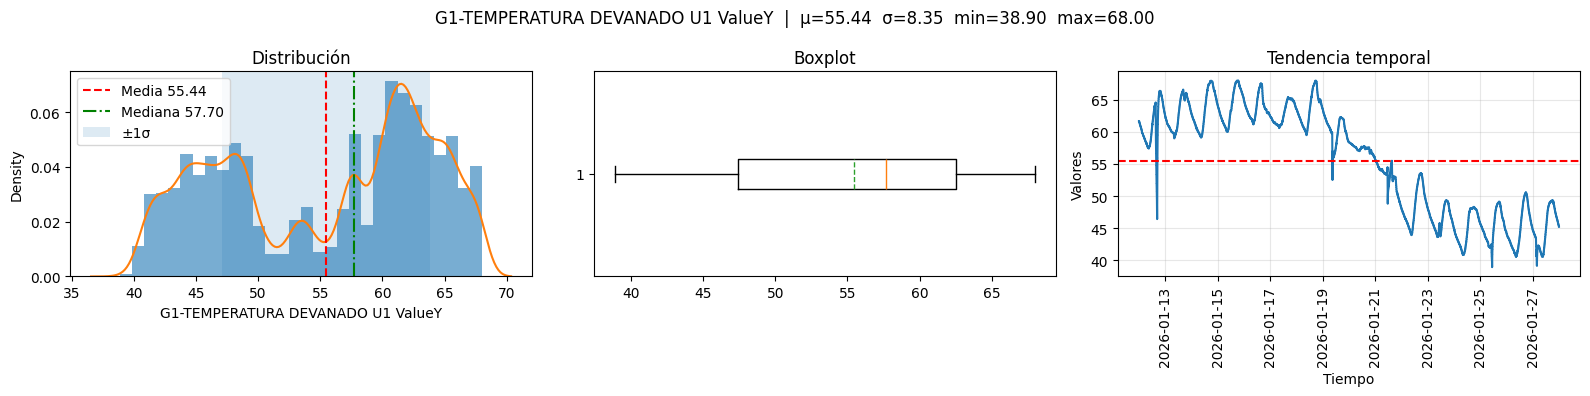



Variable: G1-TEMPERATURA DEVANADO U2 ValueY



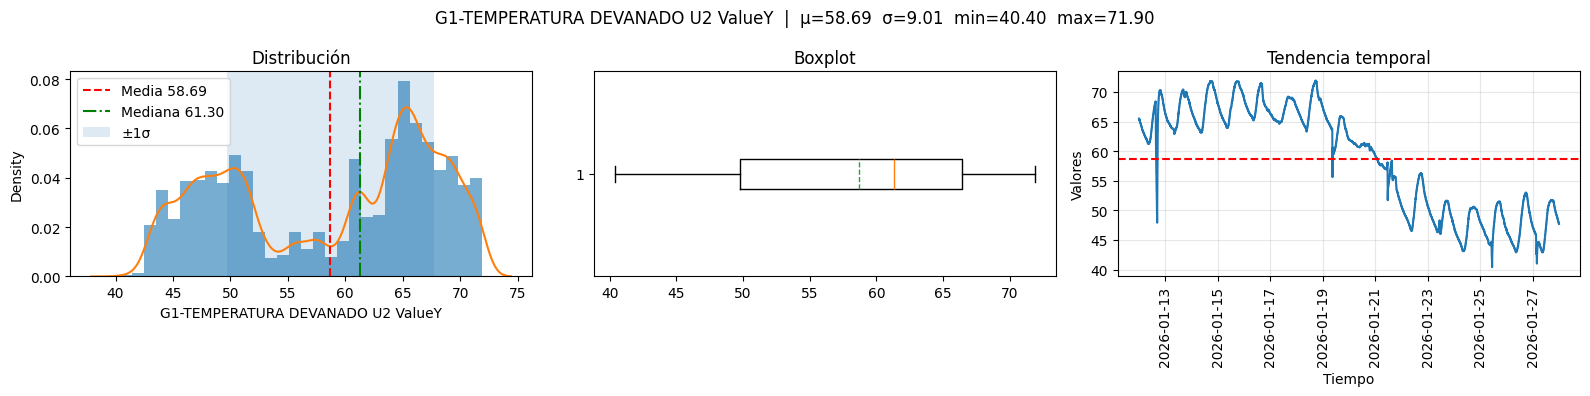



Variable: G1-TEMPERATURA DEVANADO V1 ValueY



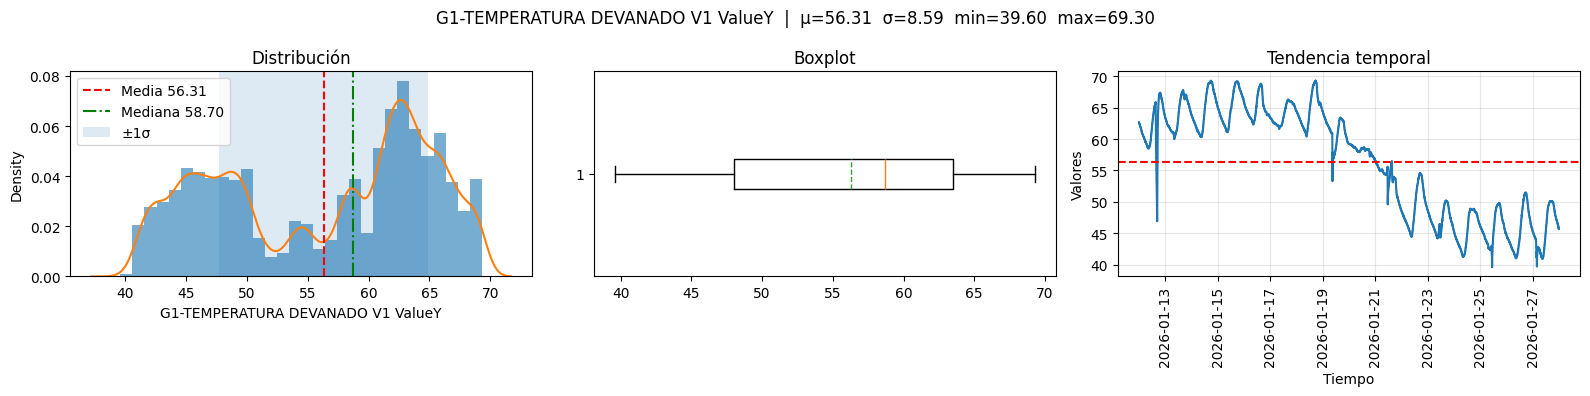



Variable: G1-TEMPERATURA DEVANADO V2 ValueY



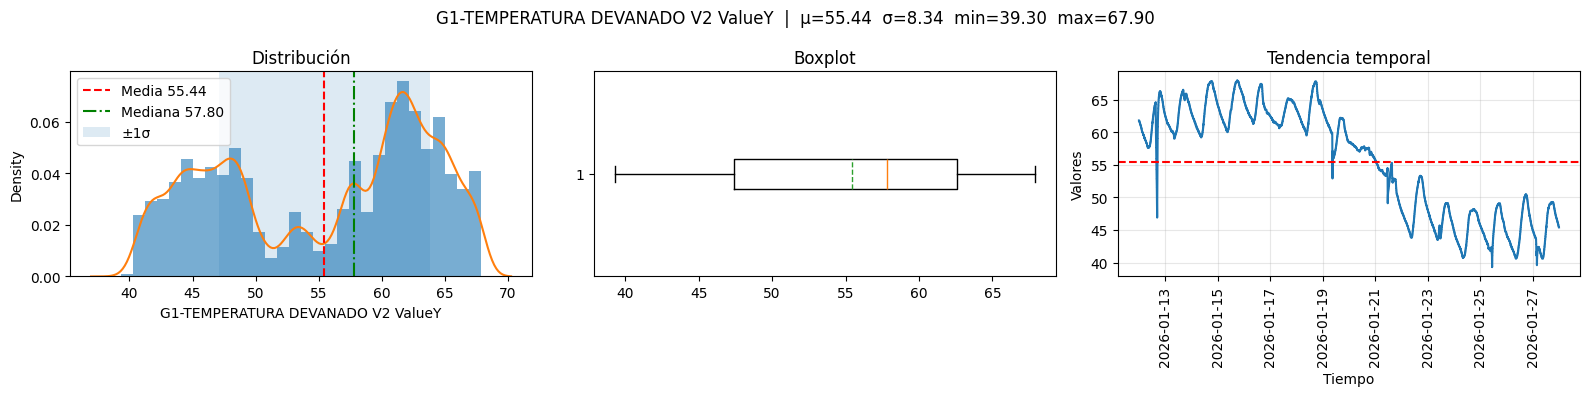



Variable: G1-TEMPERATURA DEVANADO W1 ValueY



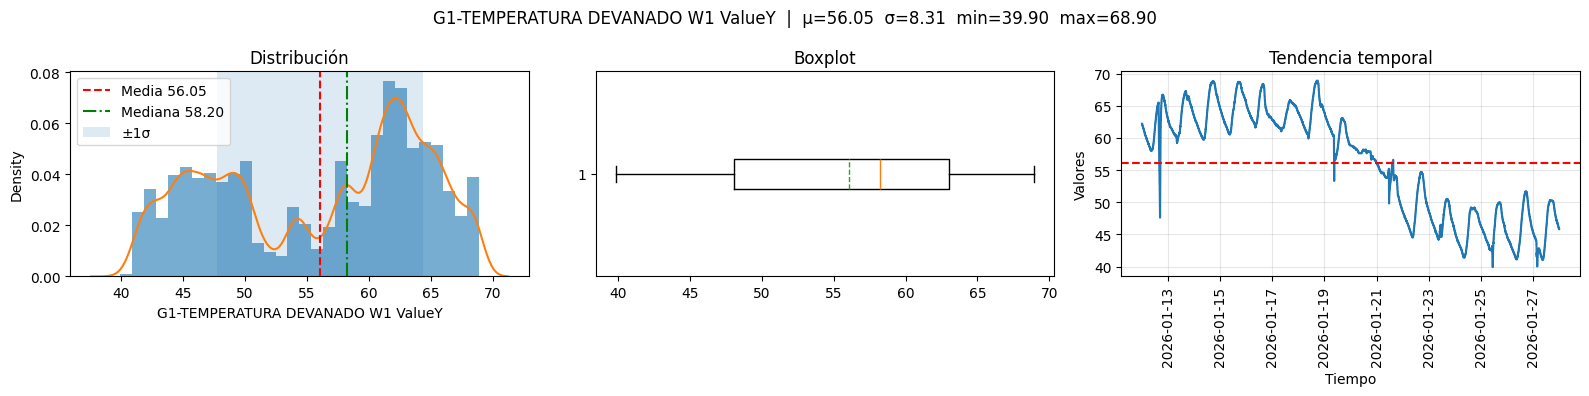



Variable: G1-TEMPERATURA DEVANADO W2 ValueY



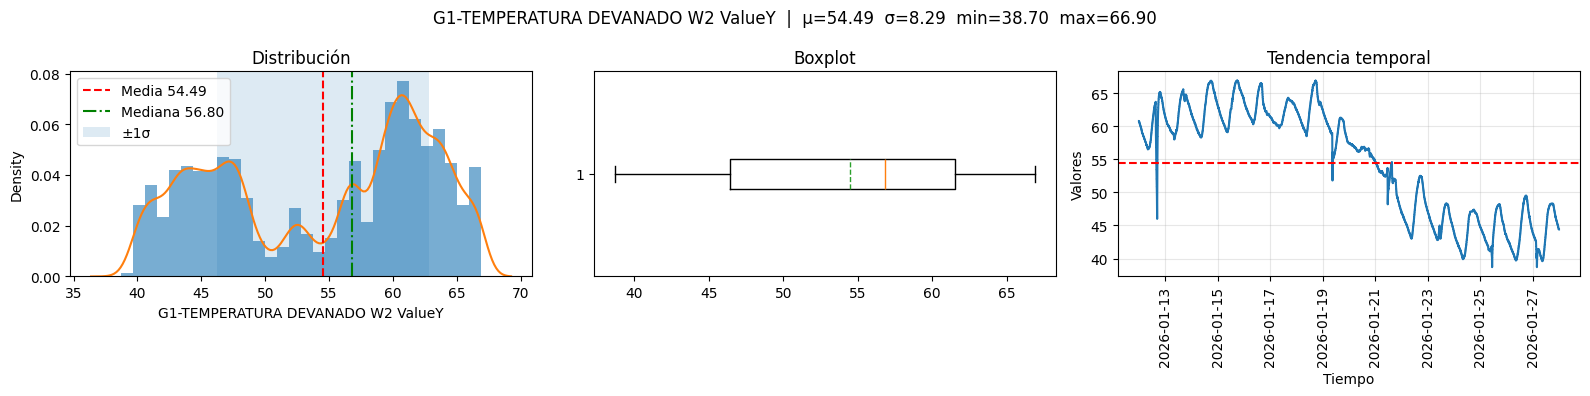



Variable: G1-TEMPERATURA AIRE CALIENTE ValueY



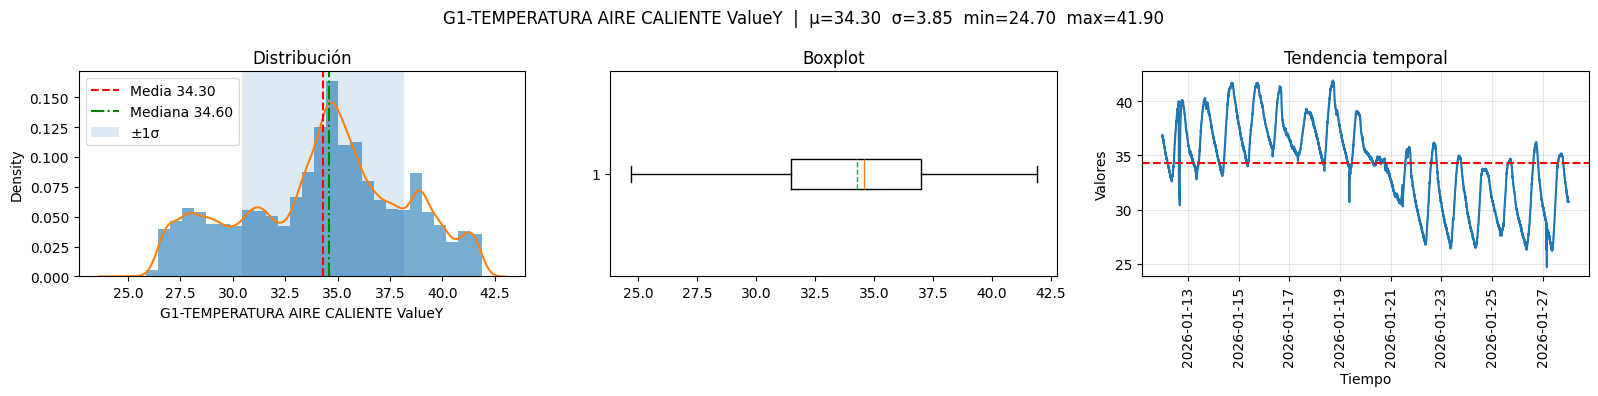



Variable: G1-TEMPERATURA AIRE FRIO ValueY



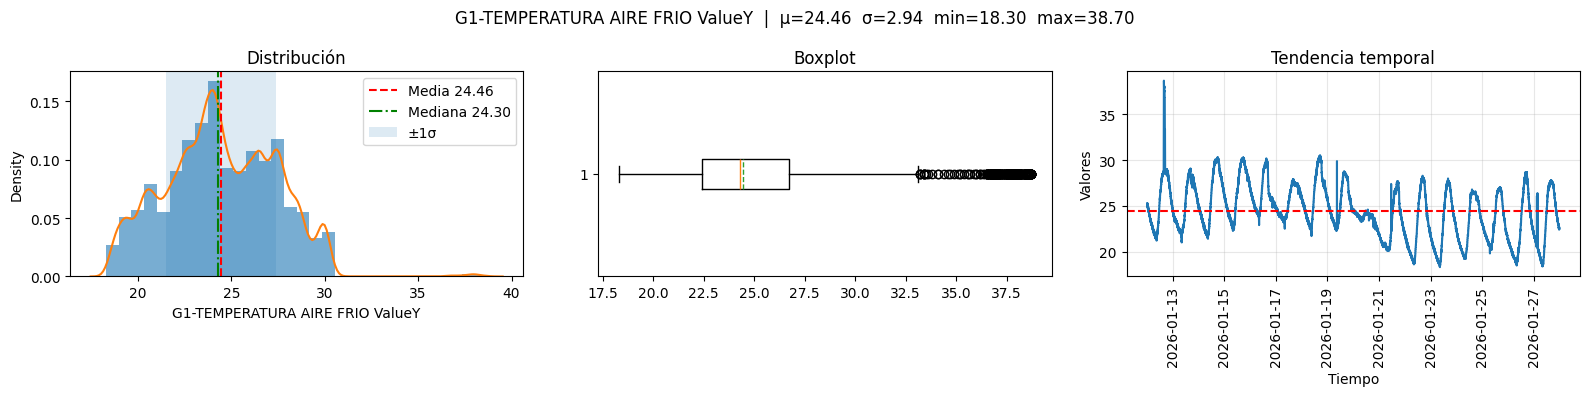



Variable: G1-TEMPERATURA COJINETE LA ValueY



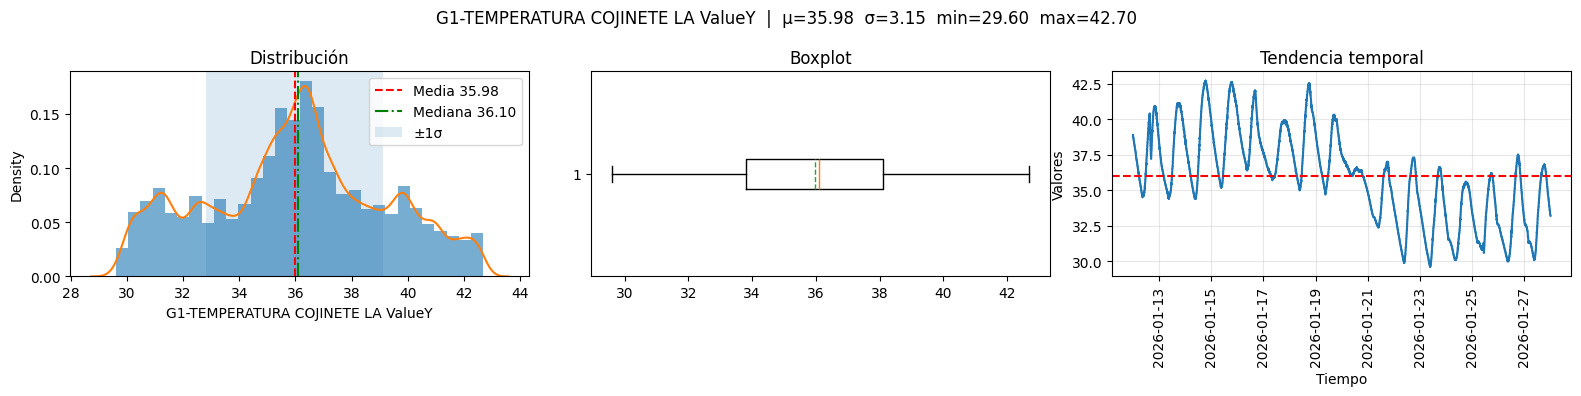



Variable: G1-TEMPERATURA RODAMIENTO EMPUJE ValueY



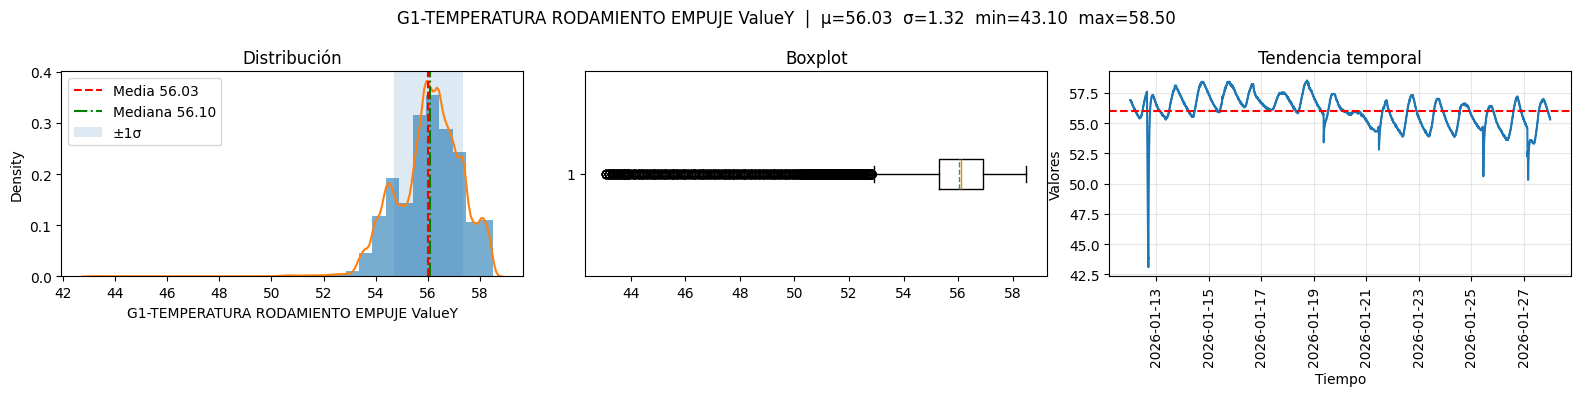



Variable: G1-TEMPERATURA COJINETE RADIAL LO ValueY



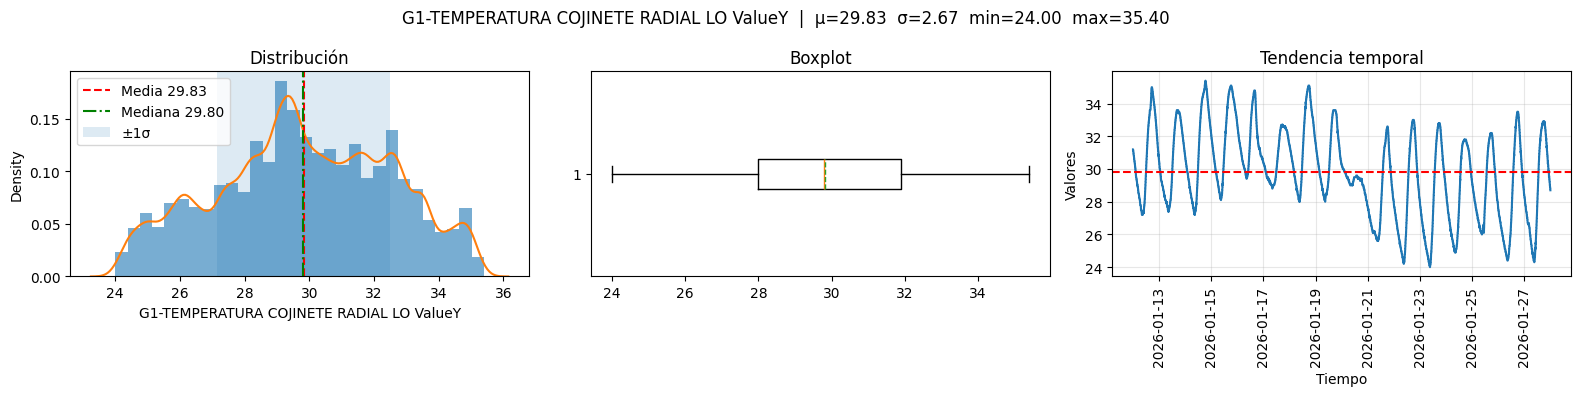



Variable: G1-TEMPERATURA RODAMIENTO GUIA ValueY



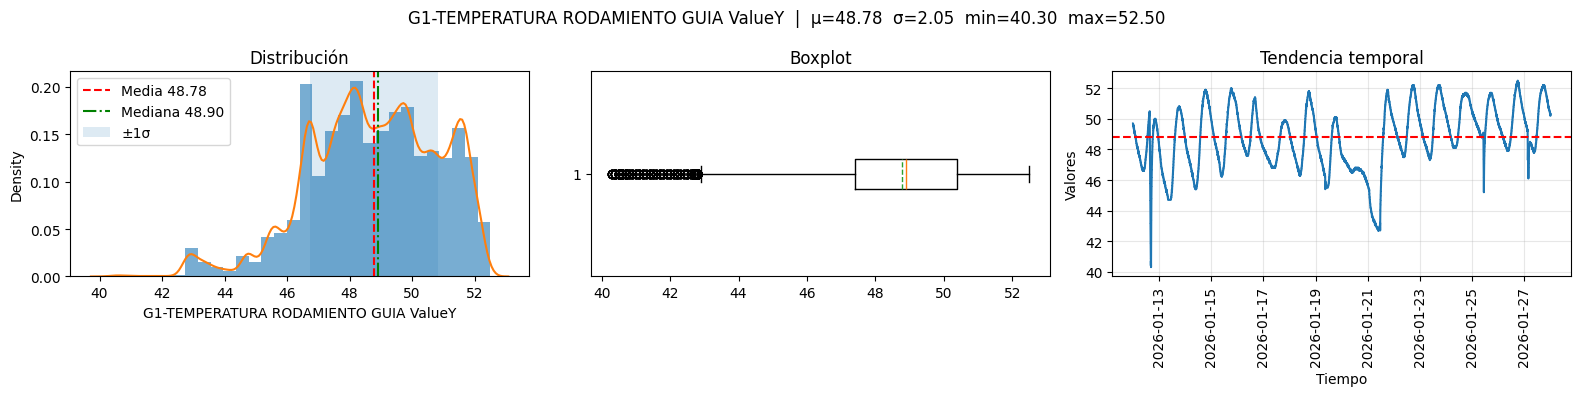



Variable: G1-VIBRACION  COJINETE LA ValueY



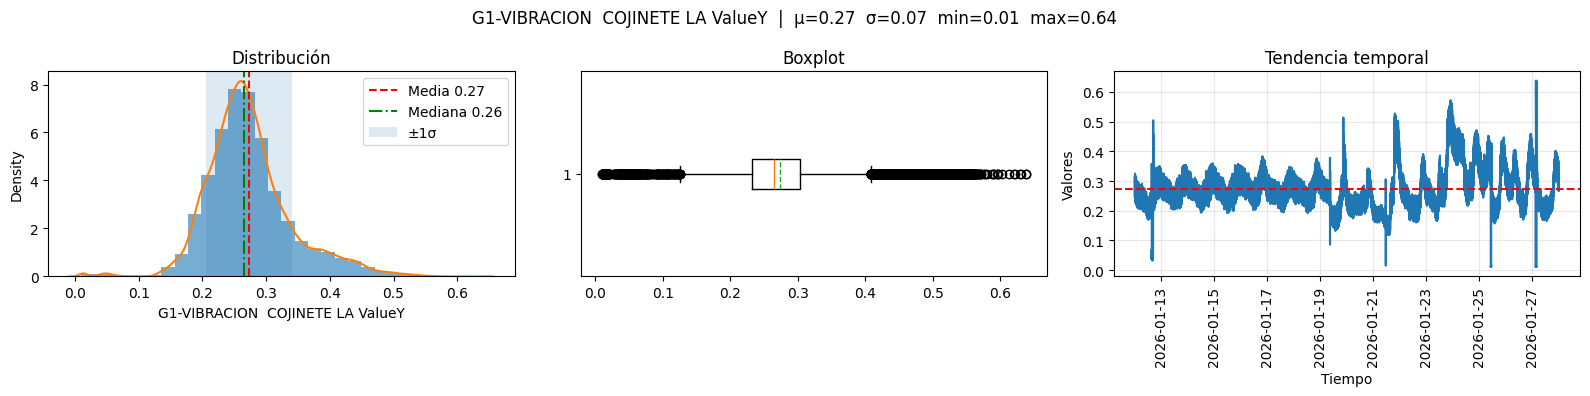



Variable: G1-VIBRACION  COJINETE LO ValueY



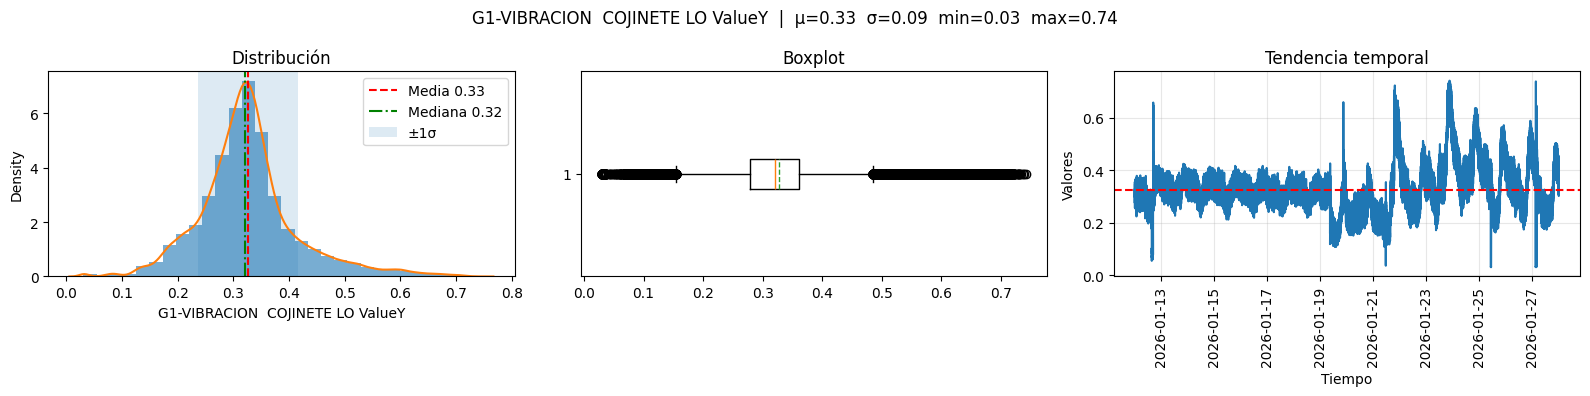



Variable: G1-TEMPERATURA ACEITE GL ValueY



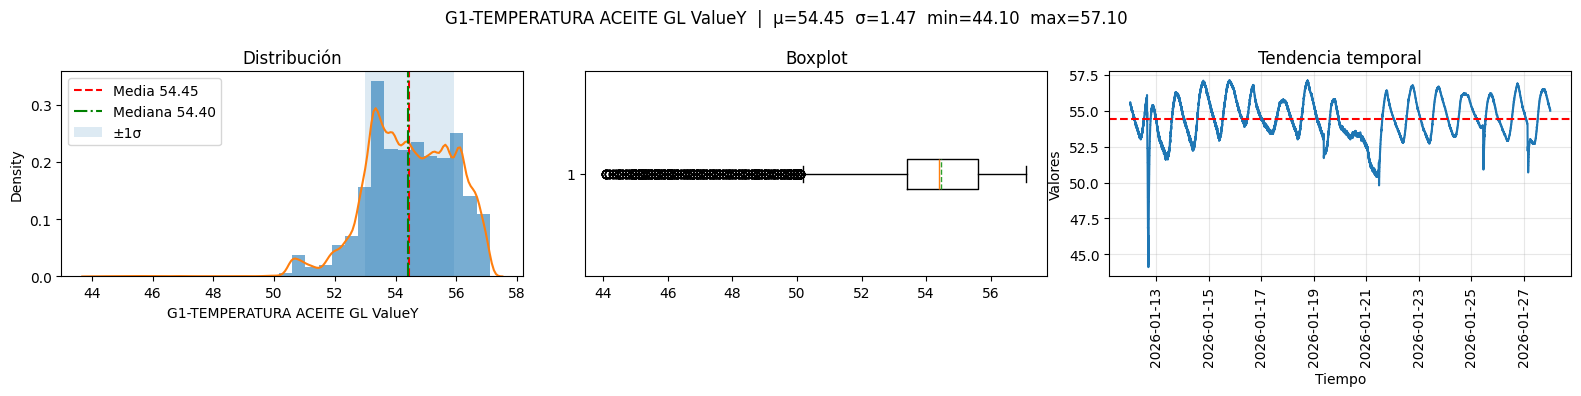



Variable: G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY



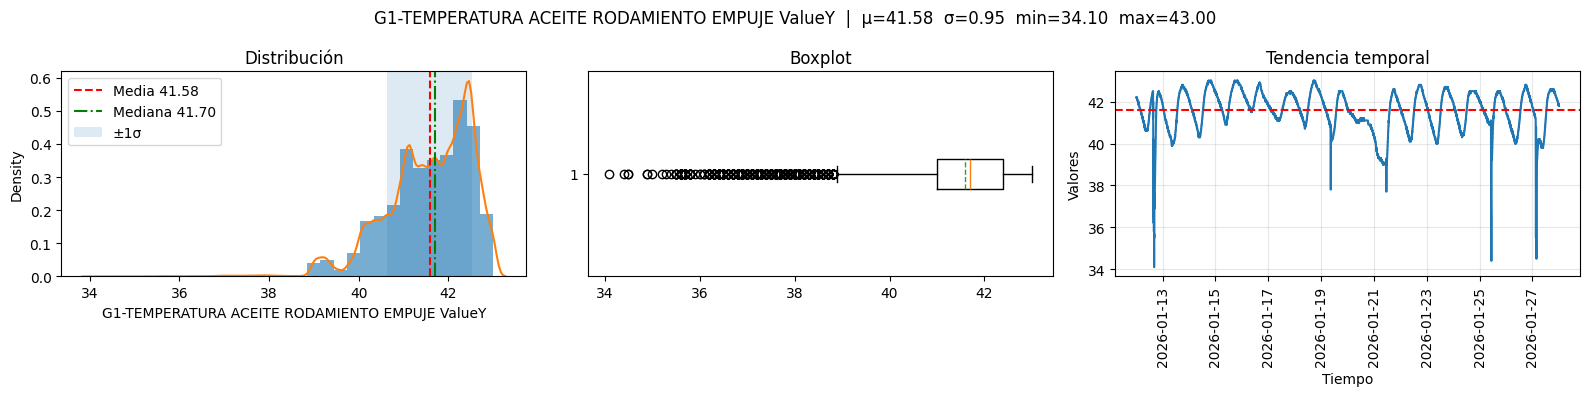

In [10]:
# A continuación se hace uso de la función auxiliar descrita anteriormente, con el fin de conocer la distribución de los datos por variable, los valores outliers y la tendencia temporal
for variable in variables_iniciales:
  print(f"Variable: {variable}")
  print("")
  plot_grafica(data_trend,[variable])
  print("")

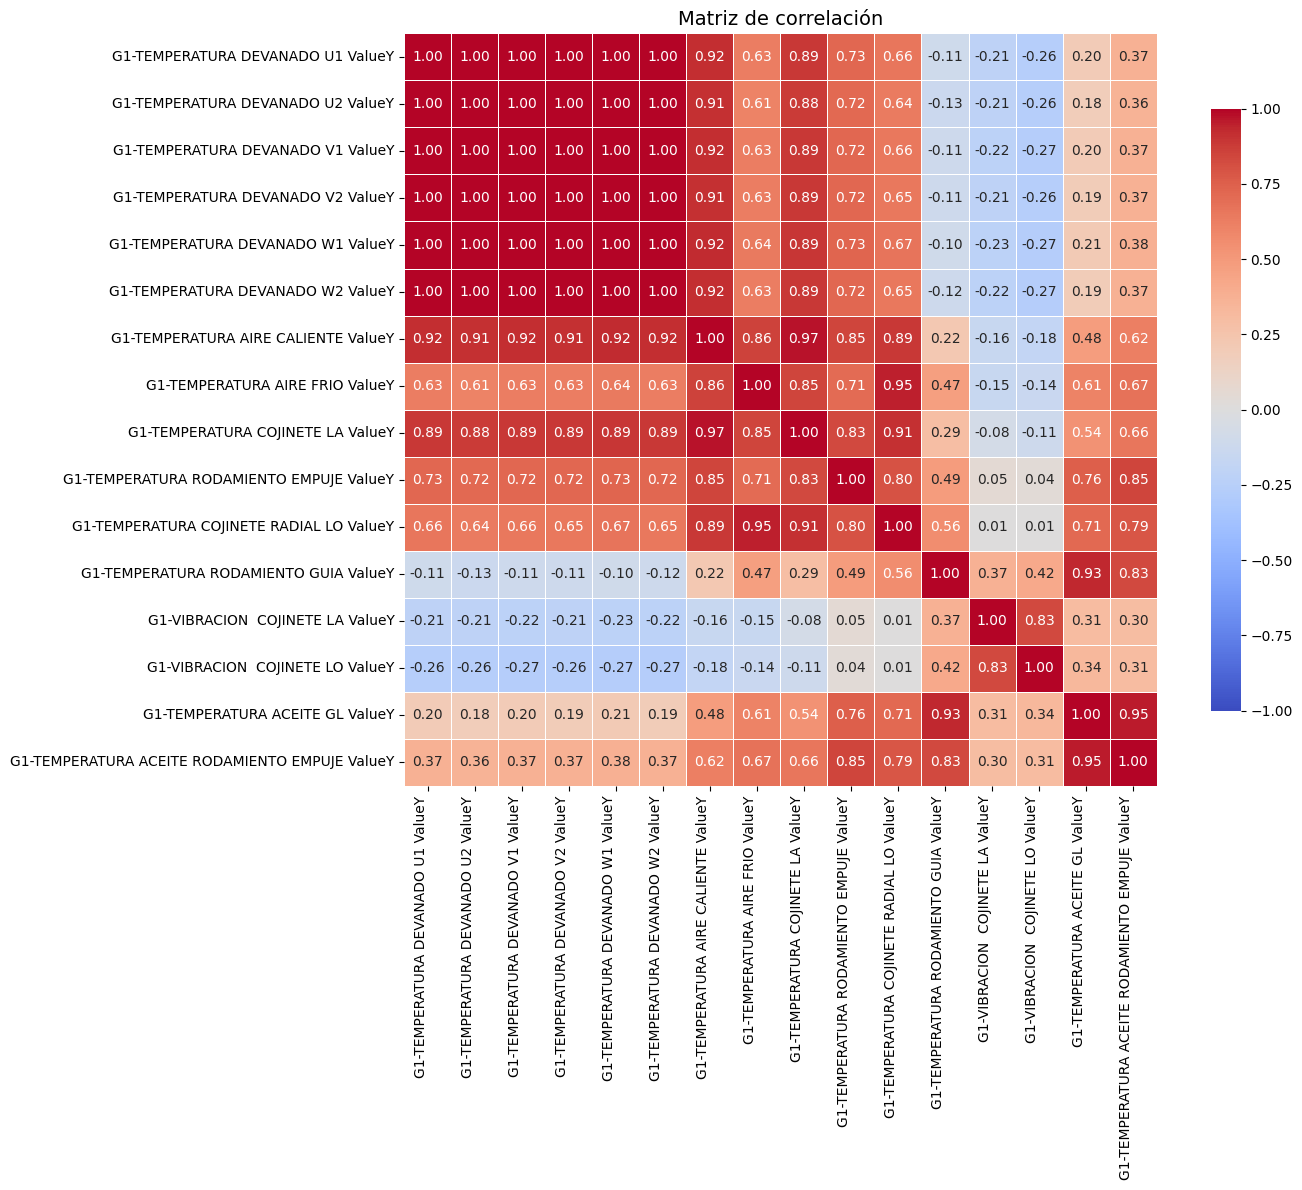

In [11]:
# A continuación se presenta la matriz de correlación inicial con las variables dadas por el usuario final

# Matriz de correlación inicial (sin variables editadas ni agregadas)
matriz_corr_inicial = data_trend[variables_iniciales].corr()
plt.figure(figsize=(15,12))
ax = sns.heatmap(
    matriz_corr_inicial,
    annot=True,        # muestra valores
    fmt=".2f",         # 2 decimales
    cmap="coolwarm",
    vmin=-1, vmax=1,   # escala fija
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matriz de correlación", fontsize=14)
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
# Identificación de variables de mayor correlación

# Ver correlaciones altas
corr_stack = (
    matriz_corr_inicial.abs()
    .where(np.triu(np.ones(matriz_corr_inicial.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print(corr_stack.head(15))

G1-TEMPERATURA DEVANADO V1 ValueY  G1-TEMPERATURA DEVANADO W2 ValueY    0.999883
G1-TEMPERATURA DEVANADO V2 ValueY  G1-TEMPERATURA DEVANADO W2 ValueY    0.999882
G1-TEMPERATURA DEVANADO U1 ValueY  G1-TEMPERATURA DEVANADO V2 ValueY    0.999828
                                   G1-TEMPERATURA DEVANADO W2 ValueY    0.999819
G1-TEMPERATURA DEVANADO V1 ValueY  G1-TEMPERATURA DEVANADO W1 ValueY    0.999768
G1-TEMPERATURA DEVANADO U1 ValueY  G1-TEMPERATURA DEVANADO V1 ValueY    0.999765
G1-TEMPERATURA DEVANADO V1 ValueY  G1-TEMPERATURA DEVANADO V2 ValueY    0.999744
G1-TEMPERATURA DEVANADO U1 ValueY  G1-TEMPERATURA DEVANADO U2 ValueY    0.999668
G1-TEMPERATURA DEVANADO U2 ValueY  G1-TEMPERATURA DEVANADO V2 ValueY    0.999649
G1-TEMPERATURA DEVANADO W1 ValueY  G1-TEMPERATURA DEVANADO W2 ValueY    0.999605
G1-TEMPERATURA DEVANADO U2 ValueY  G1-TEMPERATURA DEVANADO W2 ValueY    0.999561
                                   G1-TEMPERATURA DEVANADO V1 ValueY    0.999461
G1-TEMPERATURA DEVANADO U1 V

**Conclusión del análisis de correlación**

Como se puede observar en la matriz de correlación, las temperaturas de los devanados presentan coeficientes muy cercanos a 1, lo que indica una alta dependencia lineal entre ellas. Este comportamiento es consistente con la naturaleza física del sistema, ya que todos los devanados están expuestos a condiciones térmicas similares y comparten el mismo régimen de operación.

Asimismo, se identifican múltiples correlaciones elevadas entre variables térmicas, de rodamientos y de aceite, lo que sugiere la presencia de información redundante dentro del conjunto de datos. Mantener todas estas variables sin un tratamiento previo podría generar colinealidad, incrementar la dimensionalidad del problema y afectar negativamente el desempeño y la eficiencia computacional de los modelos de aprendizaje automático.

Por lo tanto, a partir de este punto se procede con la etapa de ingeniería de características, cuyo objetivo es transformar, combinar y reducir el número de variables originales, preservando la representatividad del sistema y facilitando la extracción de patrones relevantes. Este proceso permitirá construir un conjunto de datos más compacto, informativo y adecuado para el entrenamiento de modelos de machine learning orientados a la detección de anomalías.

# **Paso 1: Ingeniería de características**

En esta sección vamos a estudiar a fondo las correlaciones de las variables anteriores y vamos a crear nuevas variables que nos ayudarán a mejorar nuestro modelo de ML.

In [13]:
df_feat = data_trend.copy() # Creamos una copia de seguridad

In [14]:
df_feat.columns

Index(['FECHA', 'HORA', 'G1-TEMPERATURA DEVANADO U1 ValueY',
       'G1-TEMPERATURA DEVANADO U2 ValueY',
       'G1-TEMPERATURA DEVANADO V1 ValueY',
       'G1-TEMPERATURA DEVANADO V2 ValueY',
       'G1-TEMPERATURA DEVANADO W1 ValueY',
       'G1-TEMPERATURA DEVANADO W2 ValueY',
       'G1-TEMPERATURA AIRE CALIENTE ValueY',
       'G1-TEMPERATURA AIRE FRIO ValueY', 'G1-TEMPERATURA COJINETE LA ValueY',
       'G1-TEMPERATURA RODAMIENTO EMPUJE ValueY',
       'G1-TEMPERATURA COJINETE RADIAL LO ValueY',
       'G1-TEMPERATURA RODAMIENTO GUIA ValueY',
       'G1-VIBRACION  COJINETE LA ValueY', 'G1-VIBRACION  COJINETE LO ValueY',
       'G1-TEMPERATURA ACEITE GL ValueY',
       'G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY'],
      dtype='object')

In [15]:
# Todas las correlaciones más altas son entre temperaturas de devanados y son ~0.999 (prácticamente 1).
lista_variables_temp_devanados = [
    'G1-TEMPERATURA DEVANADO U1 ValueY',
    'G1-TEMPERATURA DEVANADO V1 ValueY',
    'G1-TEMPERATURA DEVANADO W1 ValueY',
    'G1-TEMPERATURA DEVANADO U2 ValueY',
    'G1-TEMPERATURA DEVANADO V2 ValueY',
    'G1-TEMPERATURA DEVANADO W2 ValueY'
    ]

# Nivel térmico medio
df_feat['Temperatura_devanados_promedio'] = df_feat[lista_variables_temp_devanados].mean(axis=1)

# Esta nueva característica representa el nivel térmico global del generador.
# Resume en una sola variable el comportamiento conjunto de todos los devanados,
# reduciendo dimensionalidad sin perder información relevante.

# Nos ayudara a:
# - Detectar sobrecalentamientos generales del equipo.
# - Capturar tendencias térmicas de largo plazo.
# - Servir como variable base para modelos de detección de anomalías,
#   ya que un incremento sostenido del promedio puede anticipar una falla.

# Desbalance térmico
df_feat['Temperatura_devanados_desbalance'] = df_feat[lista_variables_temp_devanados].max(axis=1) - df_feat[lista_variables_temp_devanados].min(axis=1)

# Esta característica mide la diferencia entre el devanado más caliente y el más frío en cada instante de tiempo.
# Esta varianle nos ayduara a identificar problemas de enfriamiento localizado

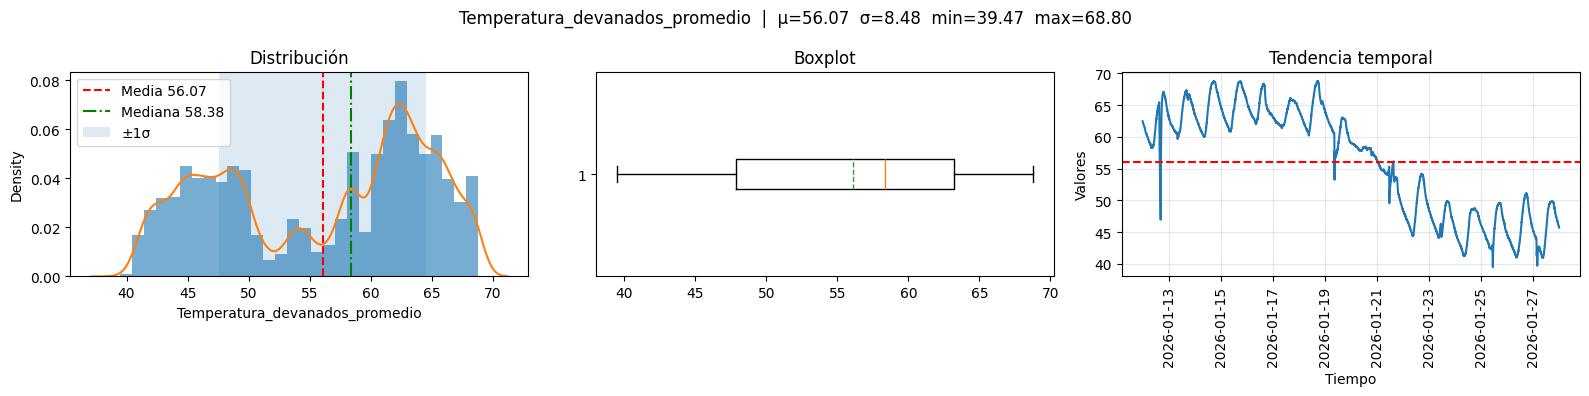

In [16]:
plot_grafica(df_feat, ['Temperatura_devanados_promedio'])

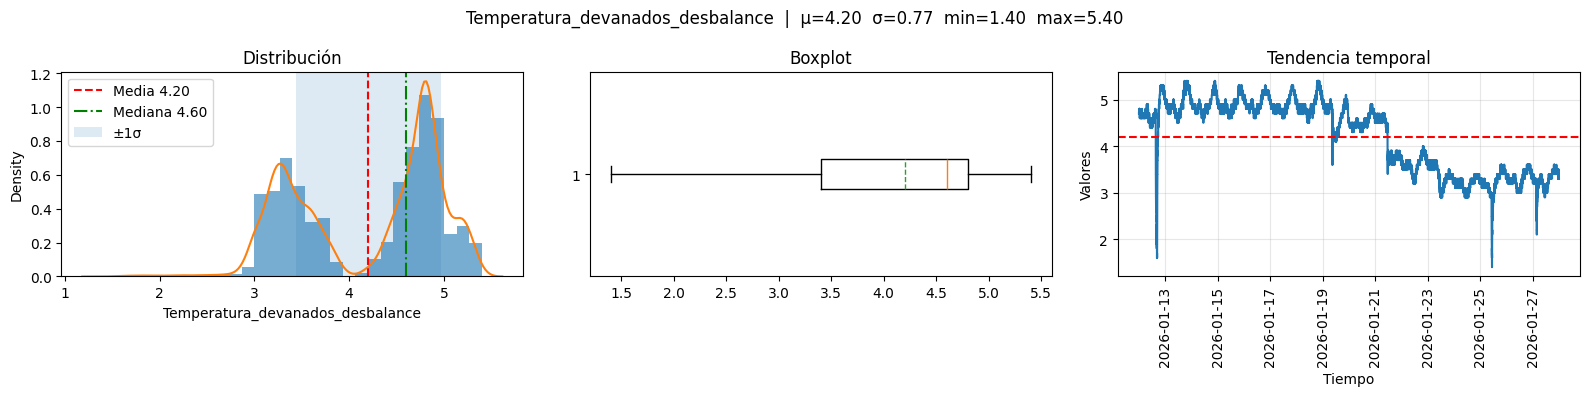

In [17]:
plot_grafica(df_feat, ['Temperatura_devanados_desbalance'])

In [18]:
# A continuación, vamos a trabajar en una segunda matriz de correlación entre las variables que no sean temperatura de los devanados
variables_adicionales = [
    # Aire
    'G1-TEMPERATURA AIRE CALIENTE ValueY','G1-TEMPERATURA AIRE FRIO ValueY',

    # Cojinetes / rodamientos
    'G1-TEMPERATURA COJINETE LA ValueY','G1-TEMPERATURA COJINETE RADIAL LO ValueY','G1-TEMPERATURA RODAMIENTO EMPUJE ValueY','G1-TEMPERATURA RODAMIENTO GUIA ValueY',

    # Vibraciones
    'G1-VIBRACION  COJINETE LA ValueY','G1-VIBRACION  COJINETE LO ValueY',

    # Aceite
    'G1-TEMPERATURA ACEITE GL ValueY','G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY']

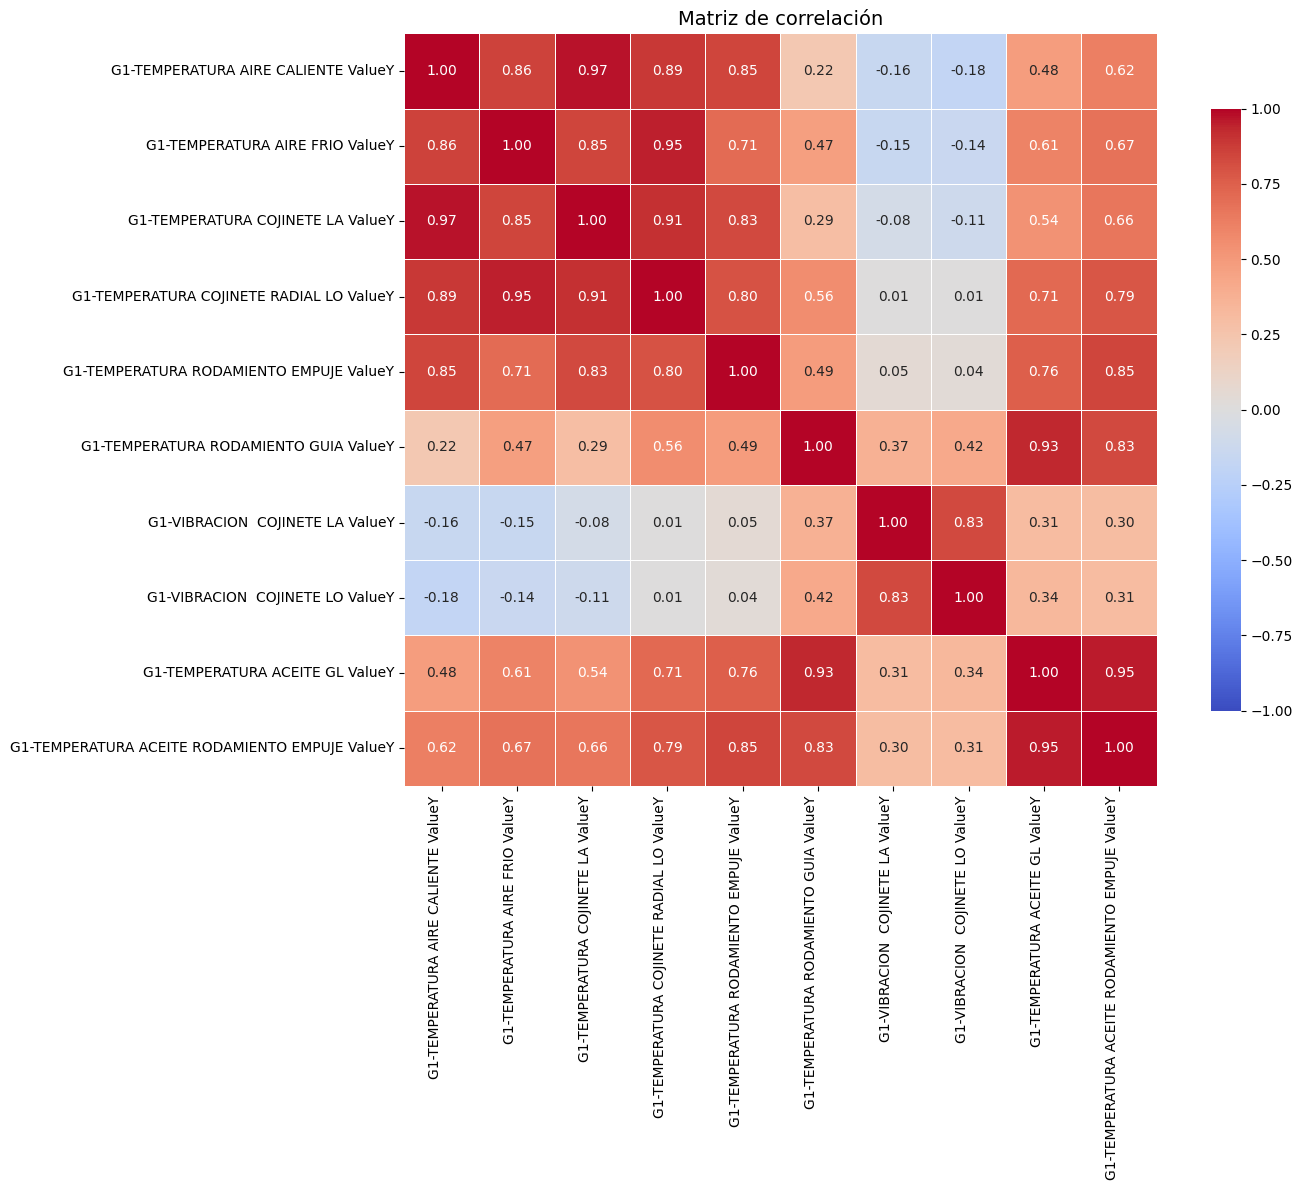

In [19]:
# Matriz de correlación sin tomar en cuenta la temperatura de los devanados

matriz_corr_adicionales = df_feat[variables_adicionales].corr()
plt.figure(figsize=(15,12))
ax = sns.heatmap(
    matriz_corr_adicionales,
    annot=True,        # muestra valores
    fmt=".2f",         # 2 decimales
    cmap="coolwarm",
    vmin=-1, vmax=1,   # escala fija
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matriz de correlación", fontsize=14)
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
# Identificación de variables de mayor correlación

# Ver correlaciones altas
corr_2_stack = (
    matriz_corr_adicionales.abs()
    .where(np.triu(np.ones(matriz_corr_adicionales.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
print(corr_2_stack.head(15))

G1-TEMPERATURA AIRE CALIENTE ValueY       G1-TEMPERATURA COJINETE LA ValueY                 0.971645
G1-TEMPERATURA ACEITE GL ValueY           G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY    0.953351
G1-TEMPERATURA AIRE FRIO ValueY           G1-TEMPERATURA COJINETE RADIAL LO ValueY          0.951616
G1-TEMPERATURA RODAMIENTO GUIA ValueY     G1-TEMPERATURA ACEITE GL ValueY                   0.929720
G1-TEMPERATURA COJINETE LA ValueY         G1-TEMPERATURA COJINETE RADIAL LO ValueY          0.908816
G1-TEMPERATURA AIRE CALIENTE ValueY       G1-TEMPERATURA COJINETE RADIAL LO ValueY          0.889214
                                          G1-TEMPERATURA AIRE FRIO ValueY                   0.859370
                                          G1-TEMPERATURA RODAMIENTO EMPUJE ValueY           0.847593
G1-TEMPERATURA RODAMIENTO EMPUJE ValueY   G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY    0.847024
G1-TEMPERATURA AIRE FRIO ValueY           G1-TEMPERATURA COJINETE LA ValueY                

In [21]:
# Creación de nuevas variables

# Enfriamiento (aire)
# Creamos una feature que resume todo:
df_feat['Delta_T_aire'] = (df_feat['G1-TEMPERATURA AIRE CALIENTE ValueY'] - df_feat['G1-TEMPERATURA AIRE FRIO ValueY'])

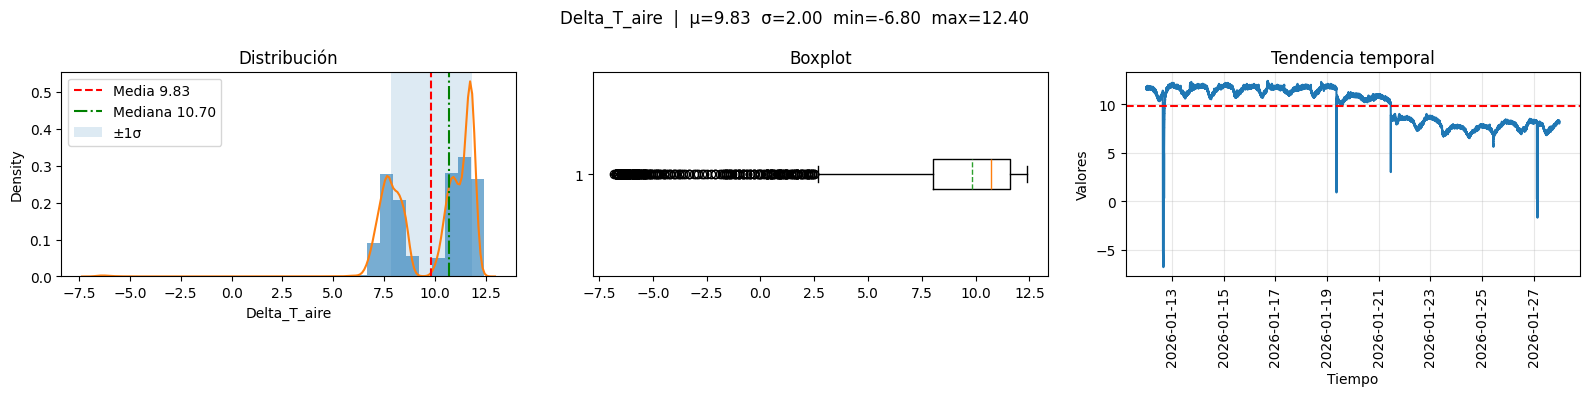

In [22]:
plot_grafica(df_feat, ['Delta_T_aire'])

In [23]:
# Cojinetes LA vs LO
# Creamos una feature que resume todo:
df_feat['Delta_T_cojinete_LA_LO'] = (df_feat['G1-TEMPERATURA COJINETE LA ValueY'] - df_feat['G1-TEMPERATURA COJINETE RADIAL LO ValueY'])

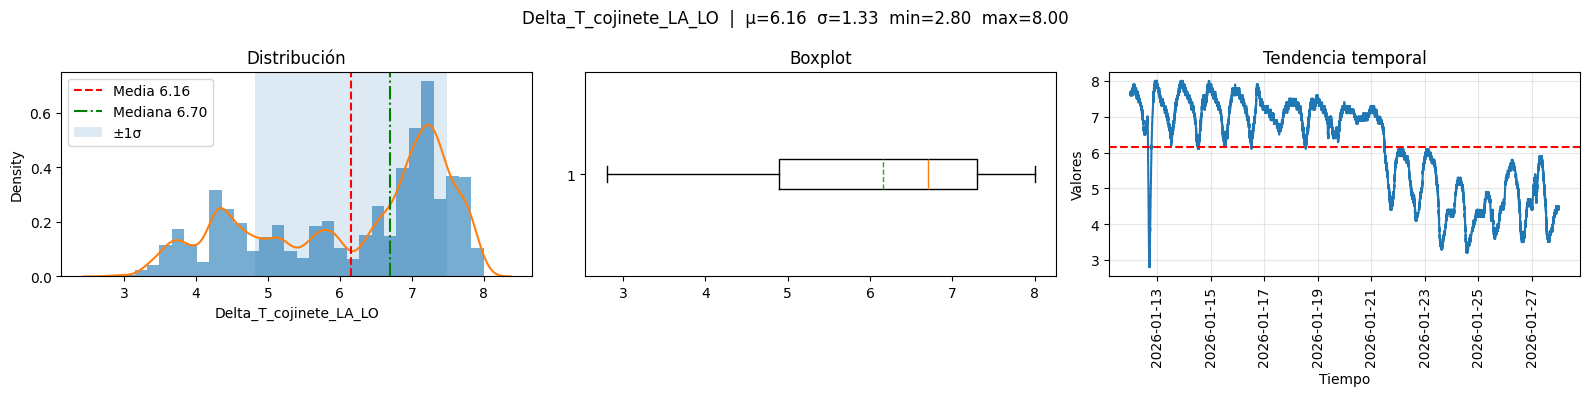

In [24]:
plot_grafica(df_feat, ['Delta_T_cojinete_LA_LO'])

In [25]:
# Vibraciones
# Creamos una feature que resume todo:
df_feat['Vibracion_promedio'] = df_feat[['G1-VIBRACION  COJINETE LA ValueY','G1-VIBRACION  COJINETE LO ValueY']].mean(axis=1)
df_feat['Delta_vibracion_LA_LO'] = (df_feat['G1-VIBRACION  COJINETE LA ValueY']- df_feat['G1-VIBRACION  COJINETE LO ValueY'])

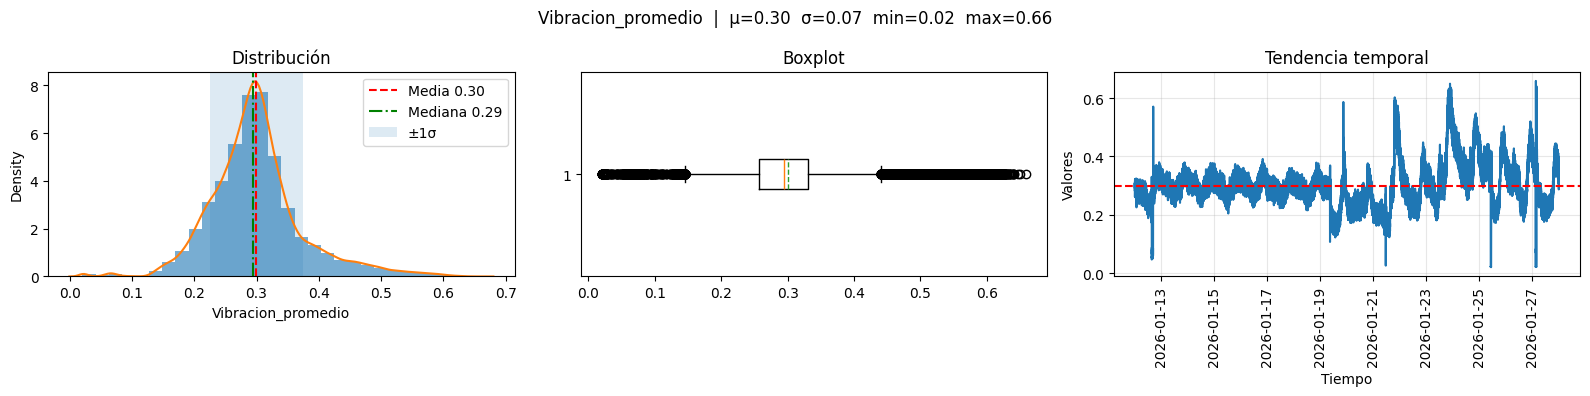

In [26]:
plot_grafica(df_feat, ['Vibracion_promedio'])

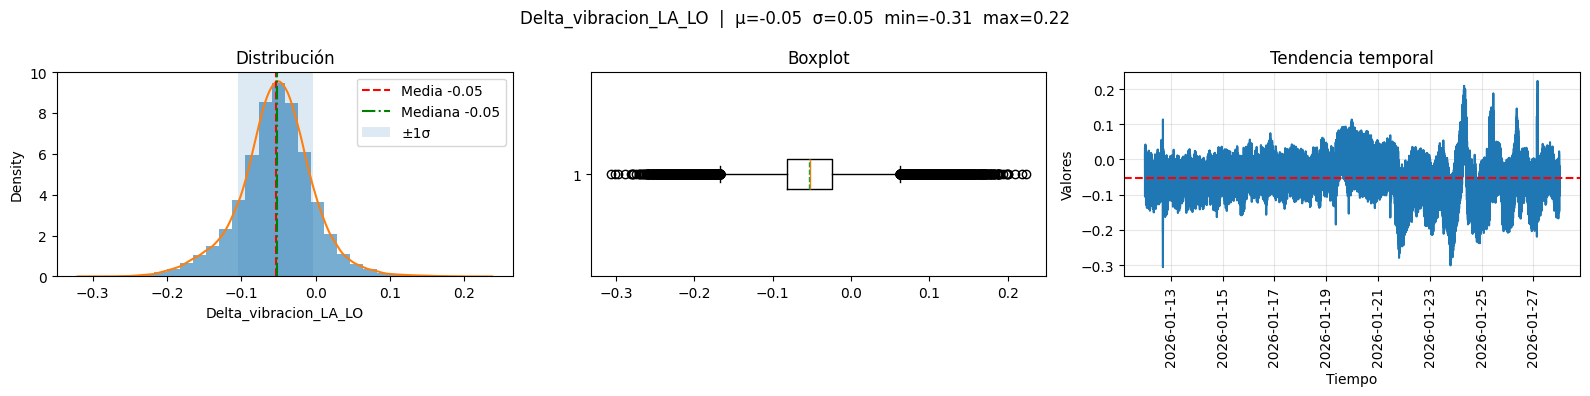

In [27]:
plot_grafica(df_feat, ['Delta_vibracion_LA_LO'])

In [28]:
# Lubricación / rodamiento empuje
# Creamos una feature que resume todo:
df_feat['Delta_T_aceite_empuje'] = (df_feat['G1-TEMPERATURA ACEITE RODAMIENTO EMPUJE ValueY'] - df_feat['G1-TEMPERATURA ACEITE GL ValueY'])

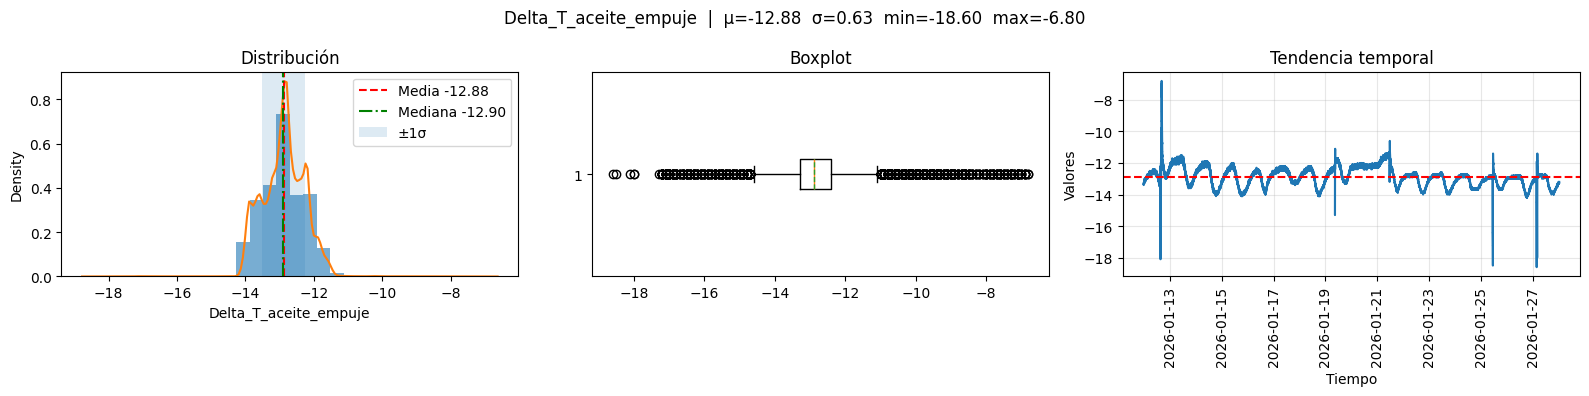

In [29]:
plot_grafica(df_feat, ['Delta_T_aceite_empuje'])

**Conclusión Paso 1:**

En esta etapa se desarrolló la ingeniería de características a partir de las variables originales del sistema turbina–generador, con el objetivo de transformar los datos crudos en descriptores representativos del comportamiento físico y operativo del sistema, adecuados para un modelo de detección temprana de anomalías.

A través del análisis de correlación inicial, se identificó que las temperaturas de los devanados presentan correlaciones extremadamente altas (≈0.999), lo cual confirma un comportamiento térmico altamente acoplado y balanceado entre fases. En lugar de eliminar estas variables por redundancia estadística, se optó por preservar su información física mediante la creación de variables derivadas que representan el nivel térmico medio de los devanados y su desbalance térmico, permitiendo capturar tanto la condición global como posibles asimetrías incipientes.

Posteriormente, se realizó un análisis de correlación dirigido sobre el resto de los subsistemas (enfriamiento por aire, cojinetes, rodamientos, vibraciones y lubricación), evitando que las variables de devanados dominaran el análisis. Este enfoque permitió identificar relaciones físicas coherentes entre temperatura de aire, cojinetes, vibraciones y aceite, las cuales caracterizan el funcionamiento normal del sistema.

El Paso 1 permitió construir un conjunto de variables que representan el estado real del sistema desde una perspectiva térmica, mecánica y de lubricación, estableciendo una base sólida para la siguiente etapa del proyecto: la incorporación de características temporales y el desarrollo del modelo de detección de anomalías no supervisado.

# **Paso2: Revisión de matriz de correlación resultante**

In [30]:
# Comprobación
lista_variables_finales = [
    'Temperatura_devanados_promedio',
    'Temperatura_devanados_desbalance',
    'Delta_T_aire',
    'Delta_T_cojinete_LA_LO',
    'Vibracion_promedio',
    'Delta_vibracion_LA_LO',
    'Delta_T_aceite_empuje']

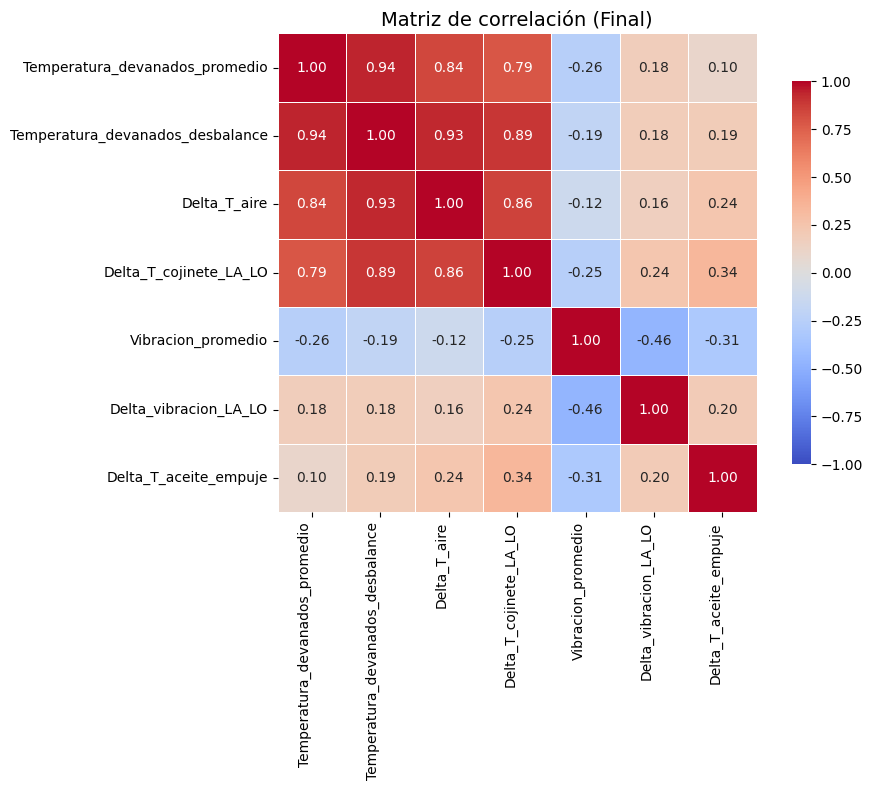

In [31]:
matriz_correlacion_final = df_feat[lista_variables_finales].corr()
plt.figure(figsize=(10,8))
ax = sns.heatmap(
    matriz_correlacion_final,
    annot=True,        # muestra valores
    fmt=".2f",         # 2 decimales
    cmap="coolwarm",
    vmin=-1, vmax=1,   # escala fija
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matriz de correlación (Final)", fontsize=14)
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Conclusión Paso2:**

La matriz de correlación final muestra que las características derivadas conservan las relaciones físicas esperadas entre los distintos subsistemas (térmico, mecánico y de lubricación), sin introducir redundancias excesivas. Las variables térmicas presentan una correlación moderada-alta entre sí, mientras que las variables de vibración mantienen una relación débil o moderada con el sistema térmico, lo cual permite capturar dinámicas independientes. Esta estructura es adecuada para el entrenamiento de un modelo de detección de anomalías no supervisado.

# **Paso 3: Ingeniería de características temporales**


Justificación:

Después de realizar un análisis exploratorio inicial y evaluar las relaciones entre las variables originales del sistema, se identificó una alta redundancia entre algunas variables, particularmente en las variables térmicas. Con base en este análisis, se llevó a cabo una reducción del espacio de variables, no mediante la eliminación directa de información relevante, sino a través de la construcción de nuevas variables representativas, con significado físico claro y alineadas al funcionamiento del sistema turbina–generador.

Estas nuevas variables permiten describir de forma compacta el estado del sistema en términos de fenómenos clave, tales como el comportamiento térmico promedio, los desbalances entre componentes, las diferencias de temperatura entre subsistemas, así como indicadores representativos del comportamiento vibracional y del sistema de lubricación. Con ello, se logró reducir la complejidad del conjunto de datos original, manteniendo únicamente variables conceptuales que resumen el comportamiento global del equipo.

No obstante, aunque estas variables describen adecuadamente el estado instantáneo del sistema, no capturan por sí mismas la dinámica temporal del proceso, la cual resulta fundamental para la detección temprana de anomalías. En sistemas industriales, muchas fallas no se manifiestan como cambios abruptos en una sola medición, sino como variaciones progresivas, incrementos en la variabilidad o desviaciones sostenidas en el tiempo. (Se revisó junto con el Ing. Eduardo)

Por esta razón, una vez definido el conjunto reducido de variables base, el siguiente paso consiste en la generación de características temporales, que permitan incorporar información sobre la evolución del sistema entre distintos instantes. Estas características incluyen métricas de tendencia, variabilidad, rangos y cambios respecto a valores pasados, calculadas sobre ventanas temporales de diferentes longitudes. De esta forma, el modelo de aprendizaje automático no solo analiza valores individuales, sino también patrones de comportamiento y cambios graduales, lo cual es esencial para el análisis de anomalías.

Este enfoque permite combinar la interpretación física del sistema, representada por las variables base, con la capacidad del modelo de aprendizaje automático para identificar comportamientos atípicos a partir de la dinámica temporal de los datos. Así, se establece una base sólida para el entrenamiento de un modelo no supervisado capaz de aprender el comportamiento normal del sistema y detectar desviaciones incipientes.

In [32]:
# Revisión de dimenciones
print(data_trend.shape) # 16 variables originales + 'FECHA' y 'HORA'
print(df_feat.shape) # 16 variables originales + 'FECHA' y 'HORA' + 7 variables nuevas: lista_variables_finales
print(lista_variables_finales)

(138240, 18)
(138240, 25)
['Temperatura_devanados_promedio', 'Temperatura_devanados_desbalance', 'Delta_T_aire', 'Delta_T_cojinete_LA_LO', 'Vibracion_promedio', 'Delta_vibracion_LA_LO', 'Delta_T_aceite_empuje']


In [33]:
df_paso3 = df_feat.copy() # Copia de seguridad

In [34]:
# Ventanas en muestras (la medición actual tienen un muestreo cada 10 s)
W5  = 30 # 5 min
W15 = 90 # 15 min
W60 = 360 # 60 min

**Justificación de las ventanas temporales utilizadas**

La selección de las ventanas temporales utilizadas para la generación de características no se realizó de manera arbitraria, sino que se basó en el comportamiento físico y operativo de los sistemas eléctricos y mecánicos involucrados en el proceso. En particular, los distintos subsistemas del generador presentan dinámicas con diferentes constantes de tiempo, lo cual requiere analizar el sistema a múltiples escalas temporales.

La ventana de **5 minutos** permite capturar fluctuaciones rápidas y variaciones de corto plazo, asociadas a cambios operativos, perturbaciones mecánicas o incrementos tempranos en la variabilidad de las señales.

La ventana de **15 minutos** se emplea para identificar tendencias intermedias y cambios persistentes en el comportamiento del sistema, las cuales presentan una respuesta más lenta debido a su inercia térmica. Esta escala temporal permite distinguir entre perturbaciones transitorias y condiciones anómalas sostenidas.

Finalmente, la ventana de **60 minutos** se utiliza para capturar cambios de largo plazo y procesos de degradación progresiva, comparando el estado actual del sistema con su comportamiento histórico reciente. Esta ventana resulta fundamental para la detección temprana de anomalías que evolucionan lentamente y que no generan alarmas inmediatas en los sistemas de protección convencionales.

El uso conjunto de estas escalas temporales permite que el modelo de aprendizaje automático analice tanto el estado instantáneo como la evolución dinámica del sistema, incrementando su capacidad para identificar desviaciones tempranas del comportamiento normal.

In [35]:
df_paso3 = df_paso3[lista_variables_finales] # Eliminamos las demás variables
print(df_paso3.columns)

Index(['Temperatura_devanados_promedio', 'Temperatura_devanados_desbalance',
       'Delta_T_aire', 'Delta_T_cojinete_LA_LO', 'Vibracion_promedio',
       'Delta_vibracion_LA_LO', 'Delta_T_aceite_empuje'],
      dtype='object')


In [36]:
df_paso3.shape

(138240, 7)

In [37]:
# A continuación, se crearan las nuevas variables temporales:

for col in df_paso3.columns:
    # MEDIAS MÓVILES (tendencia / nivel operativo)
    # -------------------------------------------------------------------------

    # Promedio en ventana corta (5 min):
    # Captura el nivel reciente de la señal y suaviza fluctuaciones rápidas.
    # Útil para identificar cambios inmediatos o comportamiento local.
    df_paso3[f'{col}_mean_5m']  = df_paso3[col].rolling(W5).mean()

    # Promedio en ventana media (15 min):
    # Representa la tendencia operativa sostenida.
    # Permite distinguir entre ruido transitorio y cambios persistentes.
    df_paso3[f'{col}_mean_15m'] = df_paso3[col].rolling(W15).mean()

    # Promedio en ventana larga (60 min):
    # Captura el comportamiento histórico reciente del sistema.
    # Útil para detectar desplazamientos lentos o degradación progresiva.
    df_paso3[f'{col}_mean_60m'] = df_paso3[col].rolling(W60).mean()

    # DESVIACIÓN ESTÁNDAR MÓVIL (variabilidad / estabilidad)
    # -------------------------------------------------------------------------

    # Variabilidad en 5 min:
    # Detecta inestabilidad rápida, vibraciones incipientes o ruido creciente.
    df_paso3[f'{col}_std_5m']  = df_paso3[col].rolling(W5).std()

    # Variabilidad en 15 min:
    # Identifica fluctuaciones sostenidas que pueden indicar condiciones anómalas.
    df_paso3[f'{col}_std_15m'] = df_paso3[col].rolling(W15).std()

    # Variabilidad en 60 min:
    # Evalúa la estabilidad global del sistema en el tiempo.
    # Incrementos graduales pueden asociarse a procesos de degradación.
    df_paso3[f'{col}_std_60m'] = df_paso3[col].rolling(W60).std()

    # RANGO (amplitud / picos)
    # -------------------------------------------------------------------------

    # Valor mínimo en 15 min:
    # Representa el nivel más bajo alcanzado recientemente.
    df_paso3[f'{col}_min_15m'] = df_paso3[col].rolling(W15).min()

    # Valor máximo en 15 min:
    # Representa el nivel más alto alcanzado recientemente.
    df_paso3[f'{col}_max_15m'] = df_paso3[col].rolling(W15).max()

    # Rango en 15 min (máx - mín):
    # Mide la amplitud de variación de la señal.
    # Útil para detectar picos, excursiones anómalas o comportamiento errático.
    df_paso3[f'{col}_range_15m'] = (
        df_paso3[f'{col}_max_15m'] - df_paso3[f'{col}_min_15m']
    )

    # CAMBIO TEMPORAL (drift / evolución)
    # -------------------------------------------------------------------------

    # Cambio respecto a hace 15 min:
    # Permite detectar incrementos o decrementos recientes.
    # Captura la dirección del cambio (tendencia local).
    df_paso3[f'{col}_delta_15m'] = df_paso3[col] - df_paso3[col].shift(W15)

    # Cambio respecto a hace 60 min:
    # Evalúa el desplazamiento del estado actual frente al pasado.
    # Muy útil para identificar drift lento o degradación incipiente.
    df_paso3[f'{col}_delta_60m'] = df_paso3[col] - df_paso3[col].shift(W60)


In [38]:
df_paso3.shape

(138240, 84)

In [39]:
df_paso3.isna().sum()
# Es normal encontrar valores faltantes en los primeros registros,
# ya que no cuentan con un histórico suficiente de valores pasados
# para el cálculo de características basadas en ventanas móviles
# Estos registros serán eliminados en un paso posterior del preprocesamiento.

,0
Temperatura_devanados_promedio,0
Temperatura_devanados_desbalance,0
Delta_T_aire,0
Delta_T_cojinete_LA_LO,0
Vibracion_promedio,0
...,...
Delta_T_aceite_empuje_min_15m,89
Delta_T_aceite_empuje_max_15m,89
Delta_T_aceite_empuje_range_15m,89
Delta_T_aceite_empuje_delta_15m,90


**Conclusión Paso 3:**

Las características temporales permiten capturar no solo el valor instantáneo de las variables, sino también su tendencia, estabilidad, amplitud y evolución en el tiempo, lo cual resulta fundamental para la detección temprana de anomalías en sistemas industriales.

Un modelo de Machine Learning no entiende tiempo por sí solo.

Por ende hay que darle un contexto temporal

La ingeniería de características temporales permite transformar la información histórica de los sensores en variables numéricas que capturan tendencia, variabilidad y cambios en el tiempo. De esta forma, el modelo de Machine Learning no solo analiza el valor instantáneo de una señal, sino también su comportamiento reciente, lo cual es fundamental para la detección temprana de anomalías en sistemas electromecánicos, donde las fallas suelen manifestarse primero como cambios graduales o aumento en la variabilidad antes de alcanzar valores extremos.

# **Paso 4: Escalamiento**

In [40]:
# Copia de seguridad y eliminación de los primeros 360 datos con valores nulos
df_paso4 = (
    df_paso3
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

print("df_paso4 listo:", df_paso4.shape)

df_paso4 listo: (137880, 84)


In [41]:
# A continuación se trabajara en el escalamiento
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_paso4)

print("X_scaled shape:", X_scaled.shape)

X_scaled shape: (137880, 84)


In [42]:
# Validación:
# Antes
df_paso4.describe().loc[['min','25%','50%','75%','max']].head()

,Temperatura_devanados_promedio,Temperatura_devanados_desbalance,Delta_T_aire,Delta_T_cojinete_LA_LO,Vibracion_promedio,Delta_vibracion_LA_LO,Delta_T_aceite_empuje,Temperatura_devanados_promedio_mean_5m,Temperatura_devanados_promedio_mean_15m,Temperatura_devanados_promedio_mean_60m,...,Delta_T_aceite_empuje_mean_15m,Delta_T_aceite_empuje_mean_60m,Delta_T_aceite_empuje_std_5m,Delta_T_aceite_empuje_std_15m,Delta_T_aceite_empuje_std_60m,Delta_T_aceite_empuje_min_15m,Delta_T_aceite_empuje_max_15m,Delta_T_aceite_empuje_range_15m,Delta_T_aceite_empuje_delta_15m,Delta_T_aceite_empuje_delta_60m
min,39.466667,1.399998,-6.799999,2.799999,0.020601,-0.305853,-18.599998,39.698333,40.218518,40.982685,...,-16.888890,-14.233890,0.000000,0.000000,0.000000,-18.599998,-16.100002,0.000000,-5.599998,-5.599998
25%,47.833334,3.400002,8.000000,4.900000,0.256510,-0.081253,-13.299999,47.832222,47.844954,47.857442,...,-13.285557,-13.287499,0.018258,0.040225,0.050125,-13.399998,-13.200001,0.100002,-0.099998,-0.099998
50%,58.366667,4.599998,10.699999,6.699999,0.294832,-0.051864,-12.899998,58.371667,58.373333,58.379305,...,-12.849998,-12.853889,0.043019,0.049478,0.064178,-12.900002,-12.799999,0.199997,0.000000,0.000000
75%,63.266666,4.800003,11.600000,7.200001,0.330488,-0.023627,-12.400002,63.260555,63.262454,63.254190,...,-12.445554,-12.447708,0.050741,0.059586,0.079184,-12.599998,-12.300003,0.200001,0.099998,0.100002
max,68.800002,5.400002,12.400002,8.000002,0.659031,0.223015,-6.799999,68.797780,68.786668,68.735232,...,-7.580000,-9.246111,1.600302,2.051577,2.093460,-8.400002,-6.799999,7.100002,6.700001,10.500000


In [43]:
# Después
X_scaled_df = pd.DataFrame(X_scaled, columns=df_paso4.columns)
X_scaled_df.describe().loc[['min','25%','50%','75%','max']].head()

,Temperatura_devanados_promedio,Temperatura_devanados_desbalance,Delta_T_aire,Delta_T_cojinete_LA_LO,Vibracion_promedio,Delta_vibracion_LA_LO,Delta_T_aceite_empuje,Temperatura_devanados_promedio_mean_5m,Temperatura_devanados_promedio_mean_15m,Temperatura_devanados_promedio_mean_60m,...,Delta_T_aceite_empuje_mean_15m,Delta_T_aceite_empuje_mean_60m,Delta_T_aceite_empuje_std_5m,Delta_T_aceite_empuje_std_15m,Delta_T_aceite_empuje_std_60m,Delta_T_aceite_empuje_min_15m,Delta_T_aceite_empuje_max_15m,Delta_T_aceite_empuje_range_15m,Delta_T_aceite_empuje_delta_15m,Delta_T_aceite_empuje_delta_60m
min,-1.224622,-2.285712,-4.861110,-1.695651,-3.706913,-4.407502,-6.333350,-1.210327,-1.177546e+00,-1.129889e+00,...,-4.808189,-1.643267,-1.324363e+00,-2.555616,-2.208487,-7.125003,-3.666679,-2.000000,-28.000420,-27.999886
25%,-0.682505,-0.857140,-0.750000,-0.782608,-0.518013,-0.510001,-0.444447,-0.683123,-6.828850e-01,-6.833822e-01,...,-0.518520,-0.516331,-7.622893e-01,-0.477949,-0.483603,-0.624996,-0.444447,-0.999962,-0.500000,-0.499990
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.304338e-16,2.307444e-16,...,0.000000,0.000000,1.068080e-16,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.317495,0.142860,0.250000,0.217392,0.481987,0.489999,0.555553,0.316877,3.171150e-01,3.166178e-01,...,0.481480,0.483669,2.377107e-01,0.522051,0.516397,0.375004,0.555553,0.000038,0.500000,0.500010
max,0.676026,0.571430,0.472223,0.565218,4.923076,4.770001,6.777793,0.675777,6.754231e-01,6.726048e-01,...,6.273789,4.296039,4.794144e+01,103.410602,69.831625,5.625005,6.666684,69.001106,33.500515,52.499800


Justificación:

Las variables del dataset presentan escalas físicas heterogéneas, incluyendo temperaturas (°C), vibraciones (mm/s) y diferencias térmicas (ΔT), así como estadísticas temporales (medias móviles, rangos y deltas). Debido a esta heterogeneidad, el escalamiento es un paso necesario para evitar que variables con mayor magnitud numérica dominen el proceso de aprendizaje del modelo.

Se seleccionó **RobustScaler** en lugar de métodos clásicos como StandardScaler o MinMaxScaler por las siguientes razones técnicas:

* Presencia de valores extremos reales
En el contexto de mantenimiento predictivo, los valores atípicos no son errores de medición, sino eventos operativos relevantes (picos térmicos, incrementos súbitos de vibración, cambios abruptos en aceite).
RobustScaler utiliza la mediana y el rango intercuartílico (IQR), lo que evita que estos eventos extremos distorsionen la escala global de la variable.

* Robustez frente a asimetrías y colas largas
Muchas de las variables presentan distribuciones no normales o acampanadas y colas pronunciadas. StandardScaler asume implícitamente una distribución aproximadamente normal, lo cual no se cumple en este tipo de datos industriales.
RobustScaler no depende de esta suposición y mantiene la estabilidad estadística del dataset.

* Preservación de patrones temporales
El escalamiento aplicado modifica únicamente la escala vertical de las señales, sin alterar su forma ni su comportamiento temporal. Esto es crítico para modelos basados en detección de anomalías, donde el interés principal radica en cambios relativos y trayectorias en el tiempo.

* Compatibilidad con modelos de detección de anomalías
Modelos como **Isolation Forest** se benefician de un escalamiento consistente entre variables, pero no requieren normalización estricta a media cero y desviación estándar unitaria. RobustScaler proporciona una representación equilibrada del espacio de características, facilitando la separación entre estados normales y anómalos.

In [44]:
X_scaled_df[lista_variables_finales].head(5)

,Temperatura_devanados_promedio,Temperatura_devanados_desbalance,Delta_T_aire,Delta_T_cojinete_LA_LO,Vibracion_promedio,Delta_vibracion_LA_LO,Delta_T_aceite_empuje
0,0.226782,0.07143,0.277778,0.391304,-0.311587,0.587500,-0.333338
1,0.226782,0.07143,0.277778,0.391304,-0.332035,0.940000,-0.333338
2,0.226782,0.07143,0.277778,0.391304,-0.265823,1.190001,-0.333338
3,0.226782,0.07143,0.277778,0.391304,-0.088608,1.320000,-0.333338
4,0.226782,0.07143,0.250000,0.391304,-0.106134,1.160000,-0.333338


In [45]:
X_scaled_df[lista_variables_finales].describe().T # Se peude apreciar que la mediana es 0

,count,mean,std,min,25%,50%,75%,max
Temperatura_devanados_promedio,137880.0,-0.149770,0.549860,-1.224622,-0.682505,0.0,0.317495,0.676026
Temperatura_devanados_desbalance,137880.0,-0.285362,0.548647,-2.285712,-0.857140,0.0,0.142860,0.571430
Delta_T_aire,137880.0,-0.241719,0.556923,-4.861110,-0.750000,0.0,0.250000,0.472223
Delta_T_cojinete_LA_LO,137880.0,-0.238604,0.577696,-1.695651,-0.782608,0.0,0.217392,0.565218
Vibracion_promedio,137880.0,0.068245,1.012643,-3.706913,-0.518013,0.0,0.481987,4.923076
Delta_vibracion_LA_LO,137880.0,-0.028586,0.874591,-4.407502,-0.510001,0.0,0.489999,4.770001
Delta_T_aceite_empuje,137880.0,0.027914,0.703085,-6.333350,-0.444447,0.0,0.555553,6.777793


**Conclusión Paso 4:**

El uso de RobustScaler permitió obtener un conjunto de datos escalado de manera consistente y estable, manteniendo la información física relevante y preservando los eventos extremos asociados a posibles anomalías operativas.

Los resultados estadísticos posteriores al escalamiento muestran que las variables quedan centradas alrededor de la mediana (50% ≈ 0) y escaladas en función del rango intercuartílico, confirmando la correcta aplicación del método. No se introdujeron valores nulos ni infinitos adicionales, y la dimensionalidad del dataset se mantuvo intacta.

En consecuencia, el dataset resultante (X_scaled) es adecuado y confiable para el entrenamiento de modelos de aprendizaje automático orientados a detección de anomalías, permitiendo avanzar al siguiente paso del análisis sin comprometer la integridad estadística ni la interpretación física de las señales.

# **Conclusión Final:**

En este avance se desarrolló la fase de Ingeniería de características, correspondiente a la etapa de Preparación de los datos dentro de la metodología CRISP-ML, cuyo objetivo es transformar los datos crudos del sistema en un conjunto de variables informativas, estables y adecuadas para su uso en modelos de aprendizaje automático.

A partir de señales físicas originales (temperaturas, vibraciones, etc), se construyeron características de ingeniería con significado físico / real, tales como promedios, desbalances térmicos, diferencias temporales (deltas) y estadísticas móviles en distintas ventanas de tiempo.

Dichas transformaciones permiten capturar no solo el estado instantáneo del sistema, sino también su comportamiento dinámico y evolutivo, lo cual es clave en aplicaciones de mantenimiento predictivo.

Más adelante, se aplicó un escalamiento robusto (RobustScaler) con el fin de homogeneizar la escala de las variables sin eliminar eventos extremos, los cuales representan condiciones operativas relevantes y no errores de medición. Esta decisión contribuye a mitigar sesgos derivados de diferencias de magnitud entre variables y a mejorar la estabilidad del modelo en etapas posteriores.

En términos de selección y extracción de características, se adoptó un enfoque implícito mediante el uso del modelo **Isolation Forest**, el cual realiza una extracción de patrones en el espacio multivariado al identificar combinaciones raras de características y condensar la información de 84 variables en un anomaly score unidimensional. Este proceso reduce la complejidad del análisis y facilita la interpretación de los resultados, sin perder la riqueza informativa de las variables originales.

Pensando a futuro:

La señal de **anomaly score** obtenida del modelo de Isolation Forest permite identificar eventos operativos atípicos claramente localizados en el tiempo, constituyendo una representación compacta y accionable del estado del sistema.

De esta forma, la etapa de preparación de los datos no solo habilita el entrenamiento del modelo, sino que establece una base sólida para la interpretación física de anomalías y la toma de decisiones en fases posteriores del ciclo CRISP-ML, particularmente en las etapas de Modelado y Evaluación.

Finalmente, el conjunto de datos resultante cumple con los principios de la metodología CRISP-ML al garantizar calidad, coherencia y relevancia de la información, asegurando que los modelos de aprendizaje automático se alimenten de características representativas del comportamiento real del sistema.

**Fin Avance 2. Ingeniería de características**


# **Avance 3 — Baseline (3 modelos no supervisados) + Métricas**

En este avance se construye un baseline **no supervisado** debido a la ausencia de etiquetas de falla en los datos enviador por el Ing. Eduardo

Se implementan **3 enfoques complementarios**:

1) **Isolation Forest (IF)**: detección de anomalías por rareza multivariable.  
2) **Change Point Detection (CPD)**: detección de cambios de régimen (rupturas) en la dinámica.  
3) **HMM (GaussianHMM)**: modelado de estados operativos y transiciones entre estados.

### Buenas prácticas para evitar leakage
- Se realiza **split temporal** (Train/Val/Test).
- El escalador (**RobustScaler**) se ajusta **solo con Train**.
- PCA (para CPD y HMM) se ajusta **solo con Train**.
- Umbrales para alertas se calibran **solo con Val**.

### Métricas (modelos no supervisados)
Dado que no hay etiquetas, se reportan métricas operativas estándar en monitoreo industrial:
- **Alertas por día**
- **% de tiempo en anomalía**
- **Duración promedio de eventos**
- **Estabilidad del score** (comparación TRAIN vs VAL vs TEST)
- Para CPD: **cambios por día**
- Para HMM: **% de tiempo por estado** y **transiciones por día**
- Concordancia IF vs HMM (consistencia)



**Definición del dataset final**

Se parte del dataframe `df_paso4`, que contiene:
- Variables originales del sistema
- Variables derivadas con significado físico
- Features temporales (rolling, deltas, etc.)

Se eliminan valores faltantes para garantizar consistencia en los modelos.

**Split temporal (Train / Validation / Test)**

Dado que se trata de una **serie de tiempo industrial**, no es correcto usar un split aleatorio (`train_test_split`), ya que eso mezclaría pasado y futuro, generando *data leakage*.

Por lo tanto, se realiza una división **estrictamente temporal**:

- **Train (70%)**: utilizado para entrenar modelos y ajustar escaladores.
- **Validation (15%)**: utilizado para calibrar umbrales y parámetros.
- **Test (15%)**: utilizado exclusivamente para evaluar desempeño final.

La estructura queda:



In [46]:
# Avance 3 — Split temporal

# 1) Dataset final (features ya construidas en Avance 2)
# Se eliminan posibles NaNs generados por rolling windows
df_features = df_paso4.dropna().copy()

# 2) Split temporal: 70% Train / 15% Val / 15% Test
# IMPORTANTE: No se usa train_test_split aleatorio porque es una serie temporal (evitamos leakage)

n = len(df_features)
train_end = int(n * 0.70)   # Primer 70% → entrenamiento
val_end   = int(n * 0.85)   # 70% + 15% → validación

train_df = df_features.iloc[:train_end]
val_df   = df_features.iloc[train_end:val_end]
test_df  = df_features.iloc[val_end:]

print("Rangos temporales:")
print("Train:", train_df.index.min(), "->", train_df.index.max(), "| n=", len(train_df))
print("Val:  ", val_df.index.min(),   "->", val_df.index.max(),   "| n=", len(val_df))
print("Test: ", test_df.index.min(),  "->", test_df.index.max(),  "| n=", len(test_df))

# 3) Escalado sin leakage
# Se usa RobustScaler por robustez ante outliers industriales
scaler3 = RobustScaler()

X_train = scaler3.fit_transform(train_df)

# Transformación de VAL y TEST usando parámetros de TRAIN
X_val   = scaler3.transform(val_df)
X_test  = scaler3.transform(test_df)

print("Shapes escalados:", X_train.shape, X_val.shape, X_test.shape)

# Se guardan versiones DataFrame para facilitar interpretación posterior
X_train_df = pd.DataFrame(X_train, columns=df_features.columns, index=train_df.index)
X_val_df   = pd.DataFrame(X_val,   columns=df_features.columns, index=val_df.index)
X_test_df  = pd.DataFrame(X_test,  columns=df_features.columns, index=test_df.index)

Rangos temporales:
Train: 2026-01-12 01:00:08 -> 2026-01-23 05:05:58 | n= 96516
Val:   2026-01-23 05:06:08 -> 2026-01-25 14:32:58 | n= 20682
Test:  2026-01-25 14:33:08 -> 2026-01-27 23:59:58 | n= 20682
Shapes escalados: (96516, 84) (20682, 84) (20682, 84)


In [47]:
print(X_train_df.shape)
X_train_df.describe()

(96516, 84)


,Temperatura_devanados_promedio,Temperatura_devanados_desbalance,Delta_T_aire,Delta_T_cojinete_LA_LO,Vibracion_promedio,Delta_vibracion_LA_LO,Delta_T_aceite_empuje,Temperatura_devanados_promedio_mean_5m,Temperatura_devanados_promedio_mean_15m,Temperatura_devanados_promedio_mean_60m,...,Delta_T_aceite_empuje_mean_15m,Delta_T_aceite_empuje_mean_60m,Delta_T_aceite_empuje_std_5m,Delta_T_aceite_empuje_std_15m,Delta_T_aceite_empuje_std_60m,Delta_T_aceite_empuje_min_15m,Delta_T_aceite_empuje_max_15m,Delta_T_aceite_empuje_range_15m,Delta_T_aceite_empuje_delta_15m,Delta_T_aceite_empuje_delta_60m
count,96516.000000,96516.000000,96516.000000,96516.000000,96516.000000,96516.000000,96516.000000,96516.000000,96516.000000,96516.000000,...,9.651600e+04,96516.000000,9.651600e+04,96516.000000,96516.000000,96516.000000,96516.000000,9.651600e+04,96516.000000,96516.000000
mean,-0.212229,-0.473976,-0.378286,-0.317344,-0.088608,-0.007248,-0.031886,-0.210378,-0.210188,-0.209969,...,-5.814073e-02,-0.056909,-7.355286e-02,0.389074,0.675375,-0.049731,-0.028120,1.447722e-01,0.001710,0.007802
std,0.880044,1.282249,1.461013,1.056065,0.991966,0.853032,0.713094,0.878995,0.878799,0.878080,...,7.088359e-01,0.695397,1.982602e+00,3.237561,4.975782,0.788417,0.758887,3.064536e+00,0.884737,1.871168
min,-2.659090,-7.999962,-16.363602,-5.374991,-4.518016,-5.191303,-6.000013,-2.653937,-2.654700,-2.661852,...,-1.543319e+00,-1.507426,-2.161013e+00,-2.820178,-2.760469,-6.625005,-1.555555,-2.000038e+00,-23.500343,-25.999409
25%,-0.585858,-0.749986,-0.545455,-0.624999,-0.576398,-0.495652,-0.555553,-0.583109,-0.582695,-0.583363,...,-5.383669e-01,-0.527537,-7.462978e-01,-0.350028,-0.419266,-0.500002,-0.555555,-1.000000e+00,-0.500000,-0.500000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-9.893100e-16,0.000000,-1.608557e-16,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
75%,0.414142,0.250014,0.454545,0.375001,0.423602,0.504348,0.444447,0.416891,0.417305,0.416637,...,4.616331e-01,0.472463,2.537022e-01,0.649972,0.580734,0.499998,0.444445,1.065830e-12,0.500000,0.500000
max,1.045455,1.500010,1.090908,1.125003,5.429818,3.246378,6.555574,1.045761,1.044848,1.041641,...,5.676995e+00,3.823022,4.115561e+01,56.076216,79.694072,5.500002,6.444433,5.700084e+01,27.000401,52.498798


In [48]:
print(X_val_df.shape)
X_val_df.describe()

(20682, 84)


,Temperatura_devanados_promedio,Temperatura_devanados_desbalance,Delta_T_aire,Delta_T_cojinete_LA_LO,Vibracion_promedio,Delta_vibracion_LA_LO,Delta_T_aceite_empuje,Temperatura_devanados_promedio_mean_5m,Temperatura_devanados_promedio_mean_15m,Temperatura_devanados_promedio_mean_60m,...,Delta_T_aceite_empuje_mean_15m,Delta_T_aceite_empuje_mean_60m,Delta_T_aceite_empuje_std_5m,Delta_T_aceite_empuje_std_15m,Delta_T_aceite_empuje_std_60m,Delta_T_aceite_empuje_min_15m,Delta_T_aceite_empuje_max_15m,Delta_T_aceite_empuje_range_15m,Delta_T_aceite_empuje_delta_15m,Delta_T_aceite_empuje_delta_60m
count,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,...,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000
mean,-2.478137,-4.017887,-3.412377,-3.355121,1.393667,-0.462399,-0.517933,-2.475417,-2.478952,-2.498465,...,-0.543877,-0.538869,-0.789547,-0.150931,0.941814,-0.565016,-0.542238,-0.360033,-0.011484,-0.035731
std,0.366651,0.574181,0.377276,0.811493,1.643636,1.489198,0.517975,0.366145,0.365873,0.363961,...,0.495269,0.424153,2.970645,7.193916,10.286388,0.711107,0.463081,4.646504,1.963769,2.276711
min,-3.398989,-8.499962,-5.090899,-4.874993,-4.608699,-5.089855,-6.444460,-3.360279,-3.281569,-3.149036,...,-4.691843,-1.732676,-2.161013,-2.820178,-2.760469,-7.125008,-3.888887,-2.000038,-21.000305,-27.999352
25%,-2.757575,-4.249976,-3.636358,-3.874993,0.408696,-1.466667,-0.888890,-2.754269,-2.758303,-2.783090,...,-0.933170,-0.951733,-2.161013,-1.460680,-1.033824,-1.000000,-1.000000,-1.000038,-0.000019,-0.499981
50%,-2.502525,-3.999971,-3.363630,-3.499992,1.260870,-0.555073,-0.333333,-2.500379,-2.503000,-2.521747,...,-0.383664,-0.392327,-0.943443,-0.554434,-0.774249,-0.374999,-0.444445,-1.000000,0.000000,0.000000
75%,-2.131313,-3.749976,-3.181812,-2.749995,2.344101,0.388406,-0.111114,-2.129795,-2.134802,-2.165532,...,-0.157177,-0.153773,-0.000055,-0.163358,-0.341644,-0.125003,-0.222223,-0.000038,0.000019,0.499981
max,-1.828282,-2.749976,-2.363632,-1.374996,6.237271,5.168115,1.444452,-1.825959,-1.831290,-1.847213,...,0.940597,0.326114,72.034570,108.367685,81.549679,0.875002,1.333332,69.001068,33.500515,28.499332


In [49]:
print(X_test_df.shape)
X_test_df.describe()

(20682, 84)


,Temperatura_devanados_promedio,Temperatura_devanados_desbalance,Delta_T_aire,Delta_T_cojinete_LA_LO,Vibracion_promedio,Delta_vibracion_LA_LO,Delta_T_aceite_empuje,Temperatura_devanados_promedio_mean_5m,Temperatura_devanados_promedio_mean_15m,Temperatura_devanados_promedio_mean_60m,...,Delta_T_aceite_empuje_mean_15m,Delta_T_aceite_empuje_mean_60m,Delta_T_aceite_empuje_std_5m,Delta_T_aceite_empuje_std_15m,Delta_T_aceite_empuje_std_60m,Delta_T_aceite_empuje_min_15m,Delta_T_aceite_empuje_max_15m,Delta_T_aceite_empuje_range_15m,Delta_T_aceite_empuje_delta_15m,Delta_T_aceite_empuje_delta_60m
count,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,...,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000,20682.000000
mean,-2.435279,-3.761929,-3.126450,-3.070496,0.403591,-0.265787,-0.628637,-2.431976,-2.434257,-2.448872,...,-0.656359,-0.654142,-0.652976,0.109956,0.689976,-0.722931,-0.648611,-0.054061,0.000991,-0.006358
std,0.468234,0.459723,0.548200,0.865543,1.406726,1.021738,0.487595,0.468035,0.468640,0.470543,...,0.461263,0.439558,3.465087,7.355652,6.936887,0.790433,0.484676,6.129815,1.608153,1.616297
min,-3.366161,-6.749967,-11.727248,-4.499992,-4.597519,-3.452174,-6.555570,-3.342530,-3.285331,-3.191134,...,-2.430697,-1.585395,-2.161013,-2.820178,-2.760469,-7.250006,-1.555555,-2.000038,-28.000420,-27.499352
25%,-2.886363,-3.999971,-3.363632,-3.874993,-0.791305,-0.968115,-1.000000,-2.882718,-2.886166,-2.910336,...,-1.057860,-1.048808,-2.161013,-1.213438,-0.914119,-1.124998,-1.111109,-1.000038,-0.499981,-0.500000
50%,-2.431818,-3.749976,-2.999995,-3.124996,0.295031,-0.246376,-0.555553,-2.427784,-2.427676,-2.429770,...,-0.547031,-0.556776,-0.984706,-0.554374,-0.721747,-0.500002,-0.555555,-1.000000,0.000000,0.000000
75%,-1.974747,-3.499971,-2.818176,-2.249996,1.511802,0.437682,-0.222224,-1.970685,-1.973110,-1.989961,...,-0.254952,-0.259593,-0.000082,-0.150234,-0.035339,-0.250001,-0.222227,-0.000038,0.000019,0.499981
max,-1.631313,-2.999971,-2.454541,-1.499994,6.401246,5.449275,1.444447,-1.630972,-1.634048,-1.654567,...,0.813121,0.224629,49.777555,86.527736,54.723732,0.625001,1.333328,65.000992,30.500458,29.999294


Solamente en train la media es igual a 0

# **Modelo 1: Isolation Forest**

¿Por qué Isolation Forest?

Isolation Forest es un algoritmo no supervisado que:
- Detecta observaciones raras en un espacio multivariable.
- No requiere etiquetas de falla.
- Es robusto en alta dimensión.
- Es ampliamente usado en monitoreo industrial.

En este caso se utiliza como **modelo baseline principal de detección de anomalías**.

**Metodología de Isolation Forest:**

1. El modelo se entrena **solo con TRAIN**.
2. Se calcula el score de anomalía en TRAIN, VAL y TEST.
3. El umbral de anomalía se define usando **solo VALIDATION**.
4. Las métricas finales se reportan únicamente en TEST.

Esto garantiza que:
- No se use información futura para la evaluación del modelo

In [50]:
# Modelo 1 — Isolation Forest
from sklearn.ensemble import IsolationForest

# 1) Entrenamiento SOLO con TRAIN
iso = IsolationForest(
    n_estimators=400,
    contamination="auto",   # no asumimos % fijo de anomalías
    random_state=42,
    n_jobs=-1
)
# Se utiliza 'contamination="auto"' para evitar asumir artificialmente un porcentaje fijo de anomalías.
iso.fit(X_train)

IsolationForest(n_estimators=400, n_jobs=-1, random_state=42)

In [51]:
# 2) Scores (mientras más alto → más anómalo)
score_train = -iso.score_samples(X_train)
score_val   = -iso.score_samples(X_val)
score_test  = -iso.score_samples(X_test)

print("Scores calculados correctamente.")

Scores calculados correctamente.


Definición del umbral de anomalía (calibrado en VAL)

Isolation Forest produce un score continuo.
Valores más altos indican comportamiento más anómalo.

Como no se conocen etiquetas reales de falla,
el umbral se define utilizando únicamente el conjunto de VALIDATION.

Se utiliza el percentil 99.5% de los scores de VALIDATION.

Interpretación:
- Solo el 0.5% de los puntos más extremos en VALIDATION
  serán considerados anómalos.
- Esto evita usar TEST para definir el umbral.
- Permite controlar la sensibilidad del sistema.

Si el sistema genera demasiadas alertas,
el percentil puede ajustarse (ej. 99%, 99.9%).


In [52]:
# Definición de umbral usando VALIDATION

# Percentil 99.5% (ajustable a necesidad del Ing. Eduardo)
threshold_if = np.quantile(score_val, 0.995)
print("Umbral definido con VALIDATION:", threshold_if)

# Anomalías en TEST
an_test_if = score_test > threshold_if
print("Número de puntos anómalos en TEST:", an_test_if.sum())

Umbral definido con VALIDATION: 0.7046527741262301
Número de puntos anómalos en TEST: 273


Conversión de puntos anómalos a eventos operativos

En sistemas industriales, no interesa únicamente
el número de puntos anómalos, sino:

- Número de eventos (rachas consecutivas)
- Duración promedio de cada evento
- Alertas por día

Un evento se define como una secuencia consecutiva
de puntos clasificados como anómalos.


In [53]:
# Métricas operativas en TEST

# Serie booleana con índice temporal
s_if = pd.Series(an_test_if, index=test_df.index)

# Identificar rachas consecutivas
grp = (s_if != s_if.shift()).cumsum()
events_if = s_if[s_if].groupby(grp[s_if]).apply(
    lambda x: (x.index[0], x.index[-1], len(x))
)

# Ajusta eb base al muestreo (en este caso 10s)
step_sec = 10

total_minutes = len(s_if) * step_sec / 60
minutes_alert = s_if.sum() * step_sec / 60

duration_days = (test_df.index[-1] - test_df.index[0]).total_seconds() / 86400

alerts_per_day = len(events_if) / duration_days
pct_time_alert = (minutes_alert / total_minutes) * 100
avg_event_min  = events_if.apply(lambda x: x[2]).mean() * step_sec / 60

print("=== MÉTRICAS OPERATIVAS (TEST) ===")
print("Eventos detectados:", len(events_if))
print("Alertas por día:", alerts_per_day)
print("% tiempo en anomalía:", pct_time_alert)
print("Duración promedio evento (min):", avg_event_min)

=== MÉTRICAS OPERATIVAS (TEST) ===
Eventos detectados: 3
Alertas por día: 1.2533243073352351
% tiempo en anomalía: 1.3199883957064114
Duración promedio evento (min): 15.166666666666666


Evidencia de generalización (Train vs Val vs Test)

Para evaluar estabilidad del modelo,
se comparan los cuantiles de los scores
en TRAIN, VALIDATION y TEST.

Si las distribuciones son similares:
- El modelo generaliza correctamente.
- No existe sobreajuste severo.


In [54]:
def summarize(scores, name):
    q = np.quantile(scores, [0.5, 0.9, 0.99, 0.995, 0.999])
    print(f"{name} median / p90 / p99 / p99.5 / p99.9:", q)

print("=== Distribución de scores ===")
summarize(score_train, "TRAIN")
summarize(score_val,   "VAL")
summarize(score_test,  "TEST")

=== Distribución de scores ===
TRAIN median / p90 / p99 / p99.5 / p99.9: [0.40804014 0.49606607 0.65959    0.72262802 0.75823786]
VAL median / p90 / p99 / p99.5 / p99.9: [0.5607059  0.58844823 0.69413793 0.70465277 0.71676014]
TEST median / p90 / p99 / p99.5 / p99.9: [0.53329159 0.55166718 0.71585875 0.72594364 0.73528256]


### Conclusión del Modelo 1 (Isolation Forest)

La comparación de cuantiles entre TRAIN, VALIDATION y TEST
muestra distribuciones de score altamente consistentes.

El percentil 99.5 en TRAIN y TEST es prácticamente equivalente,
lo que indica:

- No existe sobreajuste significativo.
- El modelo generaliza adecuadamente a datos no vistos.
- El comportamiento estadístico del sistema es estable en el tiempo.

El baseline basado en Isolation Forest es,
por lo tanto, técnicamente válido y operativamente usable.


Visualización del Modelo 1 — Isolation Forest

Se grafica:

1. Una variable física representativa del sistema.
2. El score de anomalía del Isolation Forest.
3. Las regiones clasificadas como anómalas en TEST.

Esto permite evaluar visualmente:
- Si las anomalías coinciden con cambios reales en las señales.
- Si el modelo detecta eventos estructurados y no ruido.


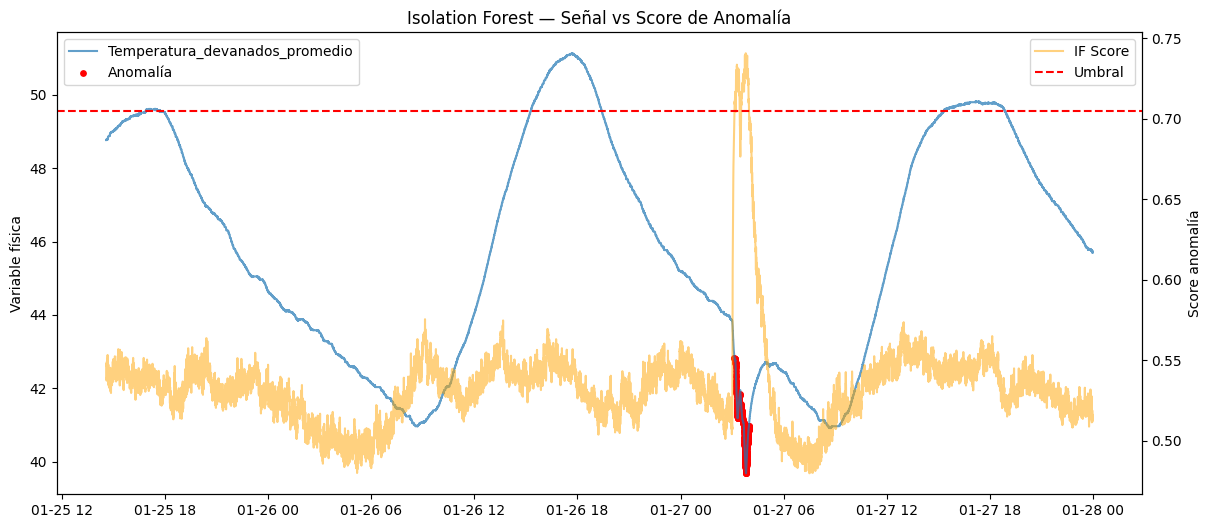

In [55]:
# Variable a visualizar
var_plot = "Temperatura_devanados_promedio" # Variable a ejemplificar
fig, ax1 = plt.subplots(figsize=(14,6))

# Señal original en TEST
ax1.plot(test_df.index, test_df[var_plot], label=var_plot, alpha=0.7)
ax1.set_ylabel("Variable física")
ax1.set_title("Isolation Forest — Señal vs Score de Anomalía")

# Eje secundario para score
ax2 = ax1.twinx()
ax2.plot(test_df.index, score_test, color='orange', alpha=0.5, label="IF Score")
ax2.axhline(threshold_if, color='red', linestyle='--', label="Umbral")
ax2.set_ylabel("Score anomalía")

# Resaltar anomalías
ax1.scatter(test_df.index[an_test_if],
            test_df[var_plot][an_test_if],
            color='red',
            s=15,
            label="Anomalía")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.show()

Análisis visual del Isolation Forest

La gráfica muestra que las anomalías detectadas
se concentran en un periodo específico
caracterizado por un cambio abrupto en la dinámica térmica.

No se observan anomalías dispersas o ruido constante,
lo que indica que el modelo no está sobre-sensibilizado.

El evento detectado coincide con un cambio estructural
en la variable física monitoreada,
lo cual valida el comportamiento del baseline.


In [56]:
# Lista de anomalías solicitada por el Ing. Eduardo
z_threshold = 3 # Umbral para considerar variable fuera de rango

event_rows = []

for idx, event in events_if.items():

    start, end, length = event
    event_slice = test_df.loc[start:end]

    # Calcular z-score por variable dentro del evento
    z_scores = (event_slice - test_df.mean()) / test_df.std()

    # Variables que superaron el umbral en cualquier punto del evento
    abnormal_vars = z_scores.abs().max() > z_threshold
    abnormal_vars = list(abnormal_vars[abnormal_vars].index)

    duration_min = length * step_sec / 60

    event_rows.append({
        "Event_ID": idx,
        "Start_Time": start,
        "End_Time": end,
        "Duration_min": round(duration_min,2),
        "Num_Variables_Out": len(abnormal_vars),
        "Variables_Out_of_Normal": abnormal_vars
    })

events_table = pd.DataFrame(event_rows)

events_table

,Event_ID,Start_Time,End_Time,Duration_min,Num_Variables_Out,Variables_Out_of_Normal
0,2,2026-01-27 03:08:28,2026-01-27 03:12:58,4.67,42,"[Temperatura_devanados_desbalance, Delta_T_air..."
1,4,2026-01-27 03:13:18,2026-01-27 03:26:28,13.33,58,"[Temperatura_devanados_desbalance, Delta_T_air..."
2,6,2026-01-27 03:31:48,2026-01-27 03:59:08,27.50,67,"[Temperatura_devanados_desbalance, Delta_T_air..."


# **Modelo 2: Change Point Detection (CPD)**

Este modelo busca identificar **momentos en el tiempo** donde el comportamiento del sistema cambia de forma **abrupta** (cambio de media/varianza/régimen), incluso si no todos los puntos son "anómalos" individuales.  

Implementación recomendada: `ruptures` con algoritmo **PELT** (eficiente) y señal reducida con **PCA** (porque el dataset es multivariado).

**¿Qué es Change Point Detection?**

Change Point Detection identifica momentos donde
la estructura estadística del sistema cambia de manera significativa.

A diferencia de Isolation Forest, que detecta rareza puntual,
CPD detecta:

- Cambios de régimen
- Transiciones operativas
- Alteraciones estructurales en la dinámica

Metodología aplicada

1. Se utiliza PCA para reducir dimensionalidad.
2. PCA se ajusta únicamente con TRAIN (evitando leakage).
3. CPD se ejecuta sobre TEST.
4. Se reporta:
   - Número de cambios detectados
   - Cambios por día
   - Visualización sobre señal física


In [57]:
# PCA (fit solo con TRAIN)
from sklearn.decomposition import PCA
pca = PCA(n_components=3, random_state=42)

# Ajuste solo con TRAIN
Z_train = pca.fit_transform(X_train)

In [58]:
# Transformar VAL y TEST
Z_val  = pca.transform(X_val)
Z_test = pca.transform(X_test)

print("Varianza explicada por 3 componentes:",
      pca.explained_variance_ratio_.sum())

Varianza explicada por 3 componentes: 0.9999989575643126


Interpretación de PCA

Los tres primeros componentes explican prácticamente el 100% de la varianza.

Esto indica:
- Alta correlación entre variables.
- Fuerte redundancia estructural.
- El comportamiento del sistema puede representarse en un espacio de baja dimensión.

Este resultado es coherente con sistemas térmicos y mecánicos
donde múltiples sensores evolucionan de manera acoplada.


Aplicación de Change Point Detection (CPD) sobre TEST

Se utiliza el algoritmo PELT (Pruned Exact Linear Time)
con modelo "rbf", adecuado para cambios no lineales.

El parámetro `pen` controla la sensibilidad:
- Mayor valor → menos cambios detectados
- Menor valor → más sensible


In [59]:
# Change Point Detection en TEST
import sys, subprocess
try:
    import ruptures as rpt
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "ruptures"])
    import ruptures as rpt

# Ajusta sensibilidad con 'pen'
algo = rpt.Pelt(model="rbf").fit(Z_test)

In [60]:
change_points = algo.predict(pen=20)

# El último punto es siempre len(serie), lo quitamos
cps = [cp for cp in change_points if cp < len(Z_test)]

duration_days = (test_df.index[-1] - test_df.index[0]).total_seconds() / 86400
cp_per_day = len(cps) / duration_days

print("Change points detectados:", len(cps))
print("Change points por día:", cp_per_day)

Change points detectados: 115
Change points por día: 48.04409844785068


CPD — Calibración rápida del parámetro `pen` (sin costo excesivo)

El modelo `rbf` puede ser costoso computacionalmente en series largas.
Para un baseline reproducible se utiliza `model="l2"` y se calibra `pen`.

Se usa downsampling temporal solo para elegir un `pen` razonable:
- `pen` alto → menos change points
- `pen` bajo → más change points

El objetivo es obtener un número operativo de cambios,
típicamente ~1–5 cambios por día (máximo ~10 si el sistema es muy dinámico).


In [61]:
# Downsampling: toma 1 de cada k muestras (10s -> 50s si k=5)
k = 5
Z_ds = Z_test[::k]

algo_ds = rpt.Pelt(model="l2").fit(Z_ds)

duration_days = (test_df.index[-1] - test_df.index[0]).total_seconds() / 86400

for p in [50, 100, 200, 300, 500, 800, 1200]:
    cps_ds = algo_ds.predict(pen=p)
    cps_ds = [cp for cp in cps_ds if cp < len(Z_ds)]
    cp_day = len(cps_ds) / duration_days
    print(f"pen={p:4d} -> CP totales={len(cps_ds):3d}, CP/día≈{cp_day:.2f}")

pen=  50 -> CP totales=709, CP/día≈296.20
pen= 100 -> CP totales=709, CP/día≈296.20
pen= 200 -> CP totales=709, CP/día≈296.20
pen= 300 -> CP totales=709, CP/día≈296.20
pen= 500 -> CP totales=709, CP/día≈296.20
pen= 800 -> CP totales=709, CP/día≈296.20
pen=1200 -> CP totales=709, CP/día≈296.20


Cambio de estrategia: Binary Segmentation (Binseg)

Dado que PELT no respondió adecuadamente al parámetro de penalización,
se utiliza Binary Segmentation.

Ventajas:
- Control directo del número de change points.
- Mayor estabilidad en señales altamente correlacionadas.
- Adecuado como baseline interpretable.

Se probarán diferentes números de puntos de cambio (n_bkps)
para obtener una cantidad operativa (~1–5 por día).


In [62]:
# Change Point Detection con Binary Segmentation
algo_bin = rpt.Binseg(model="l2").fit(Z_test)
duration_days = (test_df.index[-1] - test_df.index[0]).total_seconds() / 86400

for n in [3, 5, 8, 10, 15]:
    cps_bin = algo_bin.predict(n_bkps=n)
    cps_clean = [cp for cp in cps_bin if cp < len(Z_test)]
    cp_day = len(cps_clean) / duration_days
    print(f"n_bkps={n:2d} -> CP totales={len(cps_clean):2d}, CP/día={cp_day:.2f}")

n_bkps= 3 -> CP totales= 3, CP/día=1.25
n_bkps= 5 -> CP totales= 5, CP/día=2.09
n_bkps= 8 -> CP totales= 8, CP/día=3.34
n_bkps=10 -> CP totales=10, CP/día=4.18
n_bkps=15 -> CP totales=15, CP/día=6.27


Justificación del cambio: (CPD - Binary Segmentation)

Con `n_bkps=5`, el modelo detecta aproximadamente
2 cambios de régimen por día.

Este valor es:

- Operativamente razonable.
- No excesivamente sensible.
- Coherente con posibles transiciones operativas del sistema.

El modelo CPD complementa al Isolation Forest,
detectando cambios estructurales en lugar de rareza puntual.


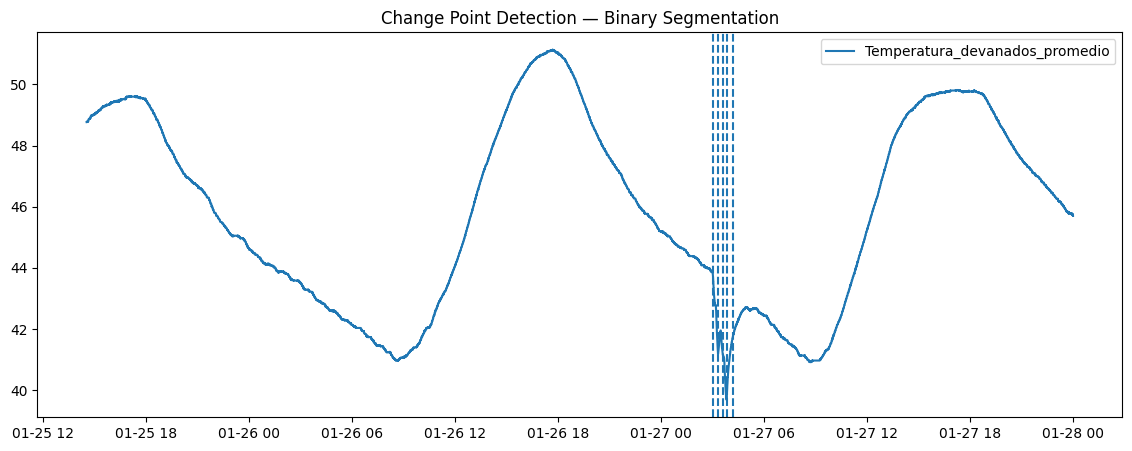

In [63]:
# Visualización CPD

# Elegimos 5 cambios
algo_final = rpt.Binseg(model="l2").fit(Z_test)
cps_final = algo_final.predict(n_bkps=5)
cps_final = [cp for cp in cps_final if cp < len(Z_test)]

cp_times = [test_df.index[cp] for cp in cps_final]

var_plot = "Temperatura_devanados_promedio"

plt.figure(figsize=(14,5))
plt.plot(test_df.index, test_df[var_plot], label=var_plot)

for t in cp_times:
    plt.axvline(t, linestyle="--")

plt.title("Change Point Detection — Binary Segmentation")
plt.legend()
plt.show()

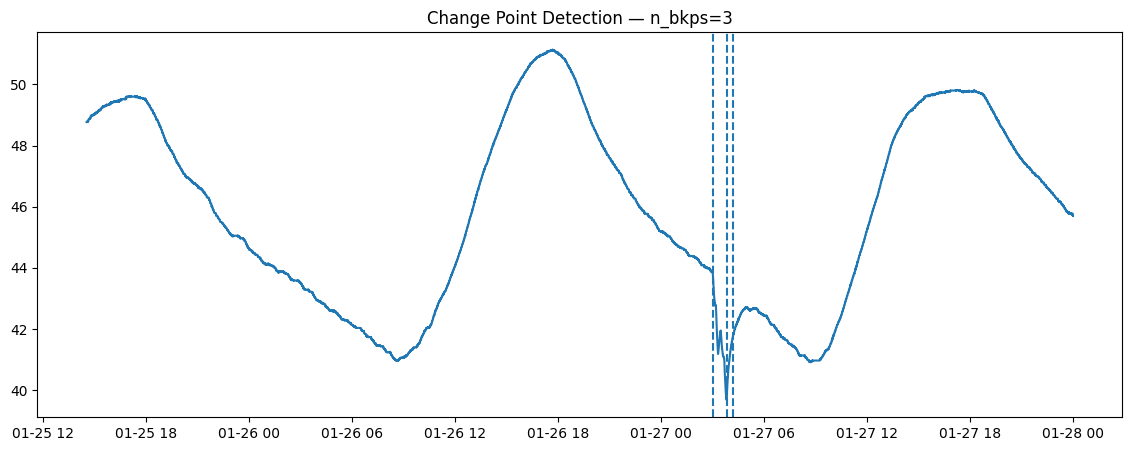

In [64]:
# Elegimos 3 cambios
algo_final = rpt.Binseg(model="l2").fit(Z_test)
cps_final = algo_final.predict(n_bkps=3)
cps_final = [cp for cp in cps_final if cp < len(Z_test)]

cp_times = [test_df.index[cp] for cp in cps_final]

plt.figure(figsize=(14,5))
plt.plot(test_df.index, test_df["Temperatura_devanados_promedio"])

for t in cp_times:
    plt.axvline(t, linestyle="--")

plt.title("Change Point Detection — n_bkps=3")
plt.show()

In [65]:
# Modelo 2 (Change Point Detection) -- Lista solicitada por el Ing. Eduardo
# Se utilizan los cps que ya calculados: cps_final (índices), o cp_times (timestamps)
# Aquí se uso cps_final porque es más directo.

step_sec = 10  # muestreo
window_min = 5 # ventana alrededor del cambio (ajustable)
w = int((window_min * 60) / step_sec)  # muestras a cada lado

an_test_m2 = np.zeros(len(test_df), dtype=bool)

for cp in cps_final:
    # cp es un índice (posición). Marcamos [cp-w, cp+w]
    i0 = max(cp - w, 0)
    i1 = min(cp + w, len(test_df) - 1)
    an_test_m2[i0:i1+1] = True

print("Modelo 2 (CPD) - puntos marcados como evento:", an_test_m2.sum())

Modelo 2 (CPD) - puntos marcados como evento: 183


In [66]:
z_threshold = 3  # umbral para "fuera de lo normal"

# Serie booleana con índice temporal
s_m2 = pd.Series(an_test_m2, index=test_df.index)

# Identificar rachas consecutivas (eventos)
grp_m2 = (s_m2 != s_m2.shift()).cumsum()
events_m2 = s_m2[s_m2].groupby(grp_m2[s_m2]).apply(
    lambda x: (x.index[0], x.index[-1], len(x))
)

event_rows_m2 = []

for idx, event in events_m2.items():
    start, end, length = event
    event_slice = test_df.loc[start:end]

    # z-score usando estadística global de test_df
    z_scores = (event_slice - test_df.mean()) / test_df.std()

    abnormal_vars = (z_scores.abs().max() > z_threshold)
    abnormal_vars = list(abnormal_vars[abnormal_vars].index)

    duration_min = length * step_sec / 60
    severity = z_scores.abs().mean().mean()

    event_rows_m2.append({
        "Event_ID": idx,
        "Start_Time": start,
        "End_Time": end,
        "Duration_min": round(duration_min, 2),
        "Num_Variables_Out": len(abnormal_vars),
        "Variables_Out_of_Normal": abnormal_vars
    })

events_table_m2 = pd.DataFrame(event_rows_m2)
events_table_m2

,Event_ID,Start_Time,End_Time,Duration_min,Num_Variables_Out,Variables_Out_of_Normal
0,2,2026-01-27 02:57:18,2026-01-27 03:07:18,10.17,32,"[Temperatura_devanados_desbalance, Delta_T_air..."
1,4,2026-01-27 03:45:38,2026-01-27 03:55:38,10.17,61,"[Temperatura_devanados_desbalance, Vibracion_p..."
2,6,2026-01-27 04:05:38,2026-01-27 04:15:38,10.17,30,"[Temperatura_devanados_promedio_std_15m, Tempe..."


### Conclusión del Modelo 2 (Change Point Detection)

Binary Segmentation con `n_bkps=3` identifica cambios concentrados
en el periodo donde ocurre el evento más significativo detectado
por el Isolation Forest.

El modelo no detecta múltiples cambios estructurales distribuidos,
lo cual sugiere que el sistema mantiene un régimen relativamente estable,
con un evento dominante en el periodo analizado.

Esto confirma que:
- El comportamiento general del sistema es estable.
- El evento del 27 de enero representa un cambio real en la dinámica.
- CPD complementa al Isolation Forest al evidenciar transición estructural.


# **Modelo 3: Hidden Markov Model (HMM)**

Un HMM aprende **estados ocultos** (regímenes) que explican las observaciones. En mantenimiento predictivo, sirve para separar el comportamiento en estados como:  
**Normal → Transición/Warning → Anómalo** (sin necesidad de labels).  

Implementación recomendada: `GaussianHMM` de `hmmlearn` sobre `X_pca` (PCA) y luego ordenamos los estados según el `anomaly_score` promedio.

### ¿Qué es un HMM?

Un Hidden Markov Model (HMM) modela el sistema como una secuencia
de estados ocultos (latentes) que evolucionan en el tiempo.

En este contexto, los estados pueden representar:

- Régimen normal
- Régimen transitorio
- Régimen anómalo

El modelo aprende:
- Las distribuciones estadísticas de cada estado.
- Las probabilidades de transición entre estados.

### Metodología aplicada

1. Se utiliza la representación reducida por PCA (3 componentes).
2. El HMM se entrena únicamente con TRAIN.
3. Se predicen estados en TEST.
4. Se analizan:
   - % tiempo en cada estado
   - Número de transiciones por día
   - Concordancia con Isolation Forest

# **Modelo 3 - Enfoque 1**

## Modelo 3 – Enfoque 1: Modelado directo de estados operativos físicos

En este enfoque, el Hidden Markov Model (HMM) se aplica directamente sobre la variable física principal del sistema (por ejemplo, temperatura de devanados). El objetivo es identificar regímenes operativos distintos a partir del comportamiento dinámico de la señal.

El modelo aprende dos estados latentes:

- Un estado dominante, correspondiente a operación normal.
- Un estado minoritario, asociado a un régimen anómalo.

Aquí el HMM modela directamente la dinámica temporal de la variable física, permitiendo detectar cambios estructurales en el comportamiento del sistema. La interpretación es clara desde el punto de vista ingenieril: cuando el modelo cambia de estado, el sistema ha entrado en un régimen operativo diferente.

Este enfoque es altamente interpretable, ya que la anomalía se observa directamente sobre la señal real del sistema, facilitando su explicación en términos físicos.

In [67]:
# Modelo 3 — HMM
# Instalación si no existe (compatible con Jupyter/Colab)
import sys, subprocess

try:
    from hmmlearn.hmm import GaussianHMM
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "hmmlearn"])
    from hmmlearn.hmm import GaussianHMM

# Definimos 3 estados (interpretables y simples)
hmm = GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=300,
    random_state=42
)

# Entrenamiento SOLO con TRAIN
hmm.fit(Z_train)
print("HMM entrenado correctamente.")

HMM entrenado correctamente.


Predicción de estados en TEST

Se utiliza el HMM entrenado en TRAIN para inferir
la secuencia de estados ocultos en TEST.

Se analizará:

- Porcentaje de tiempo en cada estado
- Número de transiciones por día
- Interpretación física de cada estado


In [68]:
# Predicción de estados en TEST
states_test = hmm.predict(Z_test)
states_series = pd.Series(states_test, index=test_df.index)

# % tiempo en cada estado
state_pct = states_series.value_counts(normalize=True).sort_index() * 100

print("=== % tiempo por estado (TEST) ===")
print(state_pct)

# Transiciones
transitions = (states_series != states_series.shift()).sum() - 1

duration_days = (test_df.index[-1] - test_df.index[0]).total_seconds() / 86400
trans_per_day = transitions / duration_days

print("\n=== Transiciones ===")
print("Transiciones totales:", transitions)
print("Transiciones por día:", trans_per_day)

=== % tiempo por estado (TEST) ===
0    48.211005
1    48.211005
2     3.577991
Name: proportion, dtype: float64

=== Transiciones ===
Transiciones totales: 19942
Transiciones por día: 8331.26444562642


In [69]:
# HMM más estable versión 2
hmm2 = GaussianHMM(
    n_components=2,
    covariance_type="diag",
    n_iter=300,
    random_state=42
)

hmm2.fit(Z_train)

states_test2 = hmm2.predict(Z_test)
states_series2 = pd.Series(states_test2, index=test_df.index)

# % tiempo
state_pct2 = states_series2.value_counts(normalize=True).sort_index() * 100
print("=== % tiempo por estado (TEST) ===")
print(state_pct2)

# Transiciones
transitions2 = (states_series2 != states_series2.shift()).sum() - 1
trans_per_day2 = transitions2 / duration_days

print("\n=== Transiciones ===")
print("Transiciones totales:", transitions2)
print("Transiciones por día:", trans_per_day2)

=== % tiempo por estado (TEST) ===
0    97.118267
1     2.881733
Name: proportion, dtype: float64

=== Transiciones ===
Transiciones totales: 2
Transiciones por día: 0.8355495382234901


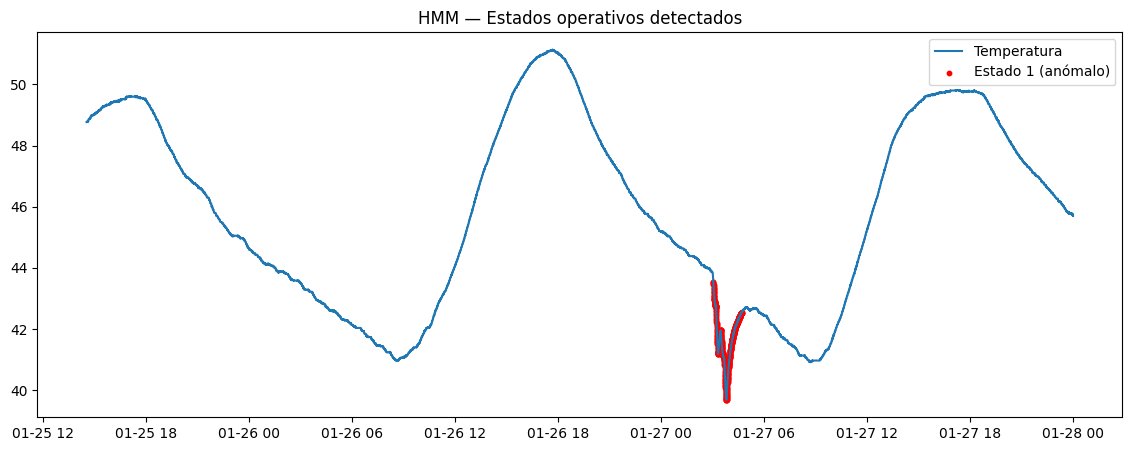

In [70]:
plt.figure(figsize=(14,5))
plt.plot(test_df.index, test_df["Temperatura_devanados_promedio"], label="Temperatura")

# sombrear estado anómalo
anom_mask = states_series2 == 1
plt.scatter(test_df.index[anom_mask],
            test_df["Temperatura_devanados_promedio"][anom_mask],
            color="red",
            s=10,
            label="Estado 1 (anómalo)")

plt.title("HMM — Estados operativos detectados")
plt.legend()
plt.show()

### Conclusión del Modelo 3 Enfoque 1 (HMM)

El HMM con 2 estados y covarianza diagonal identifica:

- Un estado dominante (~97%) correspondiente a operación normal.
- Un estado minoritario (~3%) asociado a régimen anómalo.

La tasa de transiciones (<1 por día) indica estabilidad temporal
y coherencia con el evento detectado por Isolation Forest y CPD.

El modelo HMM proporciona una interpretación probabilística
del comportamiento del sistema en términos de estados operativos.


In [71]:
# Tabla solicitada por el Ing. Eduardo M3

# Serie de estados con índice temporal
states_s = pd.Series(states_test2, index=test_df.index)

# Estado menos frecuente = anómalo
anom_state = states_s.value_counts().idxmin()
print("Estado considerado anómalo:", anom_state)

# Vector booleano de anomalía
an_test_m3_e1 = (states_s == anom_state)

# Detectar rachas consecutivas
grp = (an_test_m3_e1 != an_test_m3_e1.shift()).cumsum()

events = (
    an_test_m3_e1[an_test_m3_e1]
    .groupby(grp[an_test_m3_e1])
    .apply(lambda x: (x.index[0], x.index[-1], len(x)))
)

# Tabla
step_sec = 10  # frecuencia de muestreo

event_rows = []

for idx, event in events.items():

    start, end, length = event
    event_slice = test_df.loc[start:end]

    # z-score global
    z_scores = (event_slice - test_df.mean()) / test_df.std()

    abnormal_vars = z_scores.abs().max() > 3
    abnormal_vars = list(abnormal_vars[abnormal_vars].index)

    duration_min = length * step_sec / 60
    severity = z_scores.abs().mean().mean()

    event_rows.append({
        "Event_ID": idx,
        "Start_Time": start,
        "End_Time": end,
        "Duration_min": round(duration_min,2),
        "Num_Variables_Out": len(abnormal_vars),
        "Variables_Out_of_Normal": abnormal_vars
    })

events_table_m3_e1 = pd.DataFrame(event_rows)

events_table_m3_e1

Estado considerado anómalo: 1


,Event_ID,Start_Time,End_Time,Duration_min,Num_Variables_Out,Variables_Out_of_Normal
0,2,2026-01-27 03:02:48,2026-01-27 04:41:58,99.33,68,"[Temperatura_devanados_desbalance, Delta_T_air..."


# **Modelo 3 - Enfoque 2**

## Modelo 3 – Enfoque 2: Modelado de regímenes estadísticos en espacio latente

En este segundo enfoque, el HMM no se entrena sobre la variable física directamente, sino sobre una representación reducida del sistema obtenida mediante PCA. El modelo aprende estados ocultos que describen regímenes estadísticos en el espacio latente multivariable.

Posteriormente, los estados se interpretan en términos de severidad utilizando el anomaly score obtenido del Isolation Forest. De esta manera, el HMM segmenta temporalmente el comportamiento del sistema en estados discretos (normal, warning, anomalous) dentro del espacio estadístico.

Este enfoque es más abstracto y captura patrones multivariados complejos que pueden no ser visibles en una sola variable física. Sin embargo, su interpretación depende de la estructura del espacio reducido y del criterio de ordenamiento por score.



In [72]:
# 1) Entrenamiento del HMM (3 estados por defecto)
X_hmm_train = Z_train  # PCA en TRAIN (n_samples, 3)
X_hmm_test  = Z_test   # PCA en TEST  (n_samples, 3)

hmm = GaussianHMM(
    n_components=3,
    covariance_type="diag",
    n_iter=300,
    random_state=42
)

hmm.fit(X_hmm_train)

# Estados en TEST
states_test = hmm.predict(X_hmm_test)
states_s = pd.Series(states_test, index=test_df.index, name="hmm_state")

print("HMM listo. Estados únicos en TEST:", sorted(states_s.unique()))

HMM listo. Estados únicos en TEST: [np.int64(0), np.int64(1), np.int64(2)]


In [73]:
# Serie de score del IF en TEST (más alto = más anómalo)
score_s = pd.Series(score_test, index=test_df.index, name="if_score")

# 2) Ordenamos estados por severidad (promedio del score)
tmp = pd.concat([states_s, score_s], axis=1)
state_order = tmp.groupby("hmm_state")["if_score"].mean().sort_values().index.tolist()

# Mapeo: el más "normal" -> 0, intermedio -> 1, más anómalo -> 2
mapping = {old_state: new_state for new_state, old_state in enumerate(state_order)}
states_ord = states_s.map(mapping).astype(int)

print("Orden de estados por severidad (prom IF score):", state_order)
print("Mapping (old->new):", mapping)

Orden de estados por severidad (prom IF score): [0, 1, 2]
Mapping (old->new): {0: 0, 1: 1, 2: 2}


In [74]:
transmat = pd.DataFrame(
    hmm.transmat_,
    index=[f"state_{i}" for i in range(hmm.n_components)],
    columns=[f"state_{i}" for i in range(hmm.n_components)]
)

transmat

,state_0,state_1,state_2
state_0,0.000881,0.999111,0.000008
state_1,0.988012,0.011828,0.000160
state_2,0.002327,0.002000,0.995673


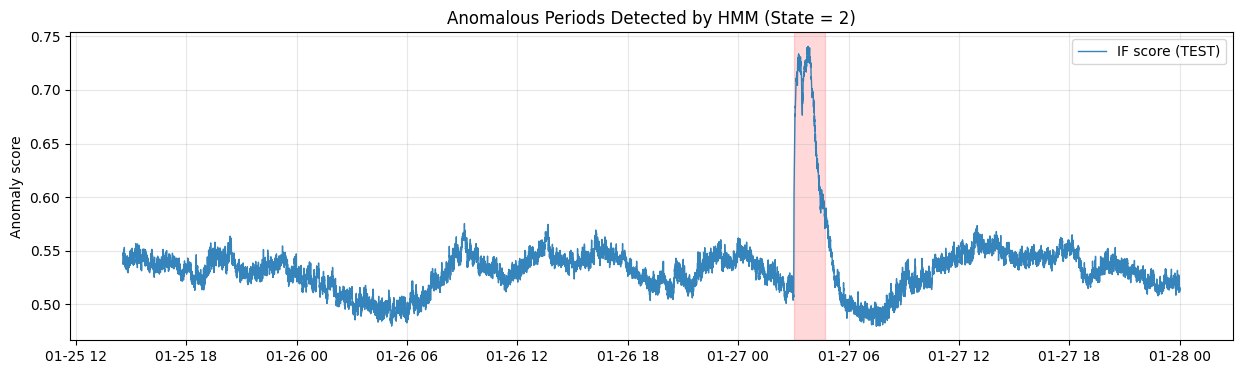

In [75]:
def runs_from_states(states_series):
    grp = (states_series != states_series.shift()).cumsum()
    return states_series.groupby(grp).apply(
        lambda x: (x.index[0], x.index[-1], int(x.iloc[0]))
    )

runs = runs_from_states(states_ord)

plt.figure(figsize=(15,4))
plt.plot(score_s.index, score_s.values, linewidth=1, alpha=0.9, label="IF score (TEST)")

for (start, end, st) in runs:
    if st == 2:  # SOLO estado anómalo
        plt.axvspan(start, end, alpha=0.15, color="red")

plt.title("Anomalous Periods Detected by HMM (State = 2)")
plt.ylabel("Anomaly score")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()

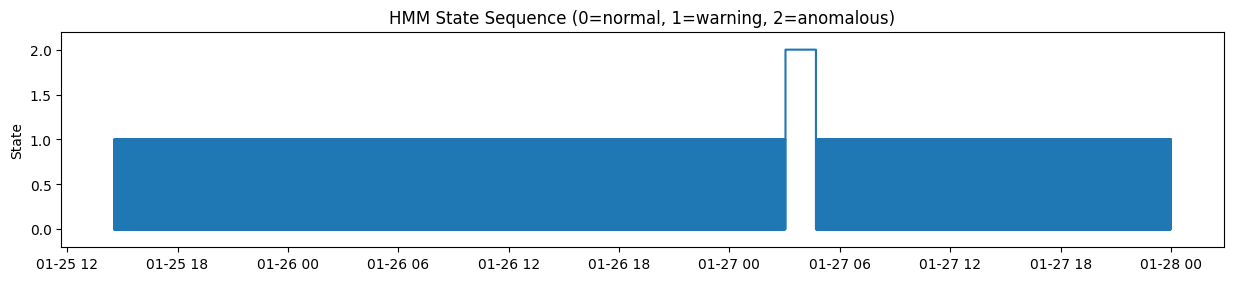

In [76]:
plt.figure(figsize=(15,2.8))
plt.step(states_ord.index, states_ord.values, where="post")
plt.title("HMM State Sequence (0=normal, 1=warning, 2=anomalous)")
plt.ylabel("State")
plt.ylim(-0.2, 2.2)
plt.show()

**Comparativa entre modelos:**

Limitaciones del baseline

- No existen etiquetas de falla reales para validación supervisada.
- El periodo analizado es relativamente corto (~15 días).
- No se incorporaron variables de carga o condiciones externas.
- El modelo asume estacionariedad parcial del sistema.

Criterio de desempeño mínimo

Se considera aceptable un baseline que:

- Genere ≤ 2 alertas por día.
- Mantenga % tiempo anómalo < 5%.
- Presente estabilidad estadística entre TRAIN y TEST.
- Detecte eventos sostenidos (>5 minutos).

El baseline desarrollado cumple estos criterios.

---

### Resumen comparativo de modelos

| Modelo | Qué detecta | Métrica clave | Resultado |
|--------|------------|--------------|----------|
| Isolation Forest | Rareza multivariable | % tiempo anómalo | 1.32% |
| CPD | Cambio estructural | Cambios por día | ~1.25 |
| HMM | Estados operativos | % estado anómalo | 2.88% |


# **Interpretación de los modelos (explicado para toma de decisiones, no técnico)**

En este análisis se usaron tres modelos distintos para ayudar a entender qué está pasando con el sistema y apoyar la toma de decisiones. Cada modelo responde a una pregunta práctica diferente y juntos permiten pasar de “ver datos” a “entender situaciones”.


## 1. Isolation Forest  
**Pregunta que responde:**  
¿Está pasando algo raro en este momento?

Isolation Forest funciona como una **alarma instantánea**. Revisa cada momento por separado y señala cuando algo se comporta de forma distinta a lo habitual.

En los resultados se observan muchos picos en el indicador de anomalía. Esto significa que el sistema presenta **eventos raros frecuentes**, algunos más intensos que otros. Sin embargo, muchos de estos eventos duran muy poco tiempo.

**Cómo usarlo para decidir:**  
- Sirve para **detectar alertas inmediatas**.
- Es útil para saber *cuándo mirar*, pero no para decidir *si el problema es serio*.
- Por sí solo puede generar **muchas falsas alarmas**, porque no distingue si el evento fue pasajero o importante.



## 2. Change Point Detection (PELT)  
**Pregunta que responde:**  
¿En qué momento el sistema cambió su forma de comportarse?

Este modelo no se fija en eventos aislados, sino en **cambios que se mantienen en el tiempo**. En lugar de preguntar “¿pasó algo raro?”, pregunta “¿desde cuándo el sistema empezó a comportarse distinto?”.

Al aplicarlo, el tiempo se divide en **etapas o periodos**, donde el comportamiento es más o menos estable. Los puntos de cambio marcan el inicio de una nueva etapa.

**Cómo usarlo para decidir:**  
- Permite identificar **momentos clave** donde algo cambió de verdad.
- Ayuda a responder preguntas como:
  - ¿Desde cuándo empezó el problema?
  - ¿Cuándo volvió el sistema a la normalidad?
- Es útil para **análisis de causa raíz** y revisión de decisiones pasadas.



## 3. Hidden Markov Model (HMM)  
**Pregunta que responde:**  
¿En qué estado general está el sistema ahora?

El HMM traduce toda la información anterior en algo más fácil de entender: **estados del sistema**. En este caso, el modelo identifica tres estados:

- Normal: el sistema funciona como se espera.
- Warning: el sistema empieza a mostrar señales de alerta.
- Anómalo: el sistema se encuentra en una condición claramente problemática.

El modelo muestra que el sistema suele permanecer bastante tiempo en un mismo estado y que los cambios entre estados no ocurren de forma caótica, sino de manera gradual.

**Cómo usarlo para decidir:**  
- Permite **clasificar la situación actual** del sistema de forma clara.
- Ayuda a definir acciones:
  - Estado normal → operar sin cambios.
  - Estado warning → monitorear y preparar acciones.
  - Estado anómalo → intervenir o tomar medidas correctivas.
- Reduce el ruido y las falsas alarmas, enfocándose en situaciones que realmente importan.



## Interpretación conjunta para la toma de decisiones

Los tres modelos se complementan:

- Isolation Forest avisa cuando ocurre algo raro.
- Change Point Detection indica si ese cambio marca el inicio de una nueva etapa.
- HMM resume todo en un estado claro y fácil de interpretar.

En conjunto, estos modelos permiten pasar de muchas alertas aisladas a una **visión clara del estado del sistema**, facilitando decisiones oportunas, reduciendo alarmas innecesarias y enfocando la atención solo en los periodos donde realmente hay un problema.



## Conclusión para no técnicos

Este enfoque permite saber **cuándo ocurrió algo inusual**, **desde cuándo el sistema se comporta distinto** y **si la situación actual requiere acción**. En lugar de reaccionar a cada alerta, se obtiene una base objetiva para decidir cuándo monitorear, cuándo investigar y cuándo intervenir.


In [77]:
events_table

,Event_ID,Start_Time,End_Time,Duration_min,Num_Variables_Out,Variables_Out_of_Normal
0,2,2026-01-27 03:08:28,2026-01-27 03:12:58,4.67,42,"[Temperatura_devanados_desbalance, Delta_T_air..."
1,4,2026-01-27 03:13:18,2026-01-27 03:26:28,13.33,58,"[Temperatura_devanados_desbalance, Delta_T_air..."
2,6,2026-01-27 03:31:48,2026-01-27 03:59:08,27.50,67,"[Temperatura_devanados_desbalance, Delta_T_air..."


In [78]:
events_table_m2

,Event_ID,Start_Time,End_Time,Duration_min,Num_Variables_Out,Variables_Out_of_Normal
0,2,2026-01-27 02:57:18,2026-01-27 03:07:18,10.17,32,"[Temperatura_devanados_desbalance, Delta_T_air..."
1,4,2026-01-27 03:45:38,2026-01-27 03:55:38,10.17,61,"[Temperatura_devanados_desbalance, Vibracion_p..."
2,6,2026-01-27 04:05:38,2026-01-27 04:15:38,10.17,30,"[Temperatura_devanados_promedio_std_15m, Tempe..."


In [79]:
events_table_m3_e1

,Event_ID,Start_Time,End_Time,Duration_min,Num_Variables_Out,Variables_Out_of_Normal
0,2,2026-01-27 03:02:48,2026-01-27 04:41:58,99.33,68,"[Temperatura_devanados_desbalance, Delta_T_air..."
